# Libraries and functions

In [1]:
"""Plot utilities for aggregated small-language-modeling NTP/RHM results.

This module works directly with the ``.npy`` dictionaries written by the
user's ``collect_file.py`` into ``collected_results/``.  It does not scan or
load the individual ``results.pt`` files.

Collected array conventions
---------------------------
* scalar seed-resolved curves:          [nP, nT, nSeeds]
* NTP curves resolved by position i:    [nP, nT, nSeeds, nPositions]
* RHM level curves:                     [nP, nT, nSeeds, L]
* RHM position-and-level curves:        [nP, nT, nSeeds, nPositions, L]

Position-resolved quantities are averaged over the position axis before they
are plotted, reproducing the convention of the earlier repository.
"""

from __future__ import annotations

from pathlib import Path
from typing import Any, Iterable
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


from pathlib import Path
import sys

# Use this when the notebook is inside a notebooks/ directory.
REPO_ROOT = Path("..").resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

def load_collected_results(
    filename: str | Path,
    *,
    collected_results_dir: str | Path = "collected_results",
) -> dict[str, Any]:
    """Load one aggregated ``.npy`` result dictionary.

    ``filename`` may be:

    * an explicit path, e.g. ``collected_results/my_run.npy``;
    * a basename, e.g. ``my_run.npy``;
    * a basename without extension, e.g. ``my_run``.
    """
    path = Path(filename).expanduser()
    if path.suffix == "":
        path = path.with_suffix(".npy")

    if not path.exists():
        candidate = Path(collected_results_dir).expanduser() / path
        if candidate.exists():
            path = candidate
        else:
            raise FileNotFoundError(
                f"Could not find collected result file {filename!r}. Tried:\n"
                f"  {Path(filename).expanduser()}\n"
                f"  {candidate}"
            )

    loaded = np.load(path, allow_pickle=True)
    if isinstance(loaded, np.ndarray) and loaded.shape == ():
        data = loaded.item()
    else:
        data = loaded

    if not isinstance(data, dict):
        raise TypeError(
            f"Expected {path} to contain a dictionary saved with np.save(...), "
            f"but found {type(data)!r}."
        )

    required = ("P_values", "num_seeds")
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError(f"Collected file {path} is missing required keys: {missing}")

    if "T_arr" not in data and "epoch_values" not in data:
        raise KeyError(
            f"Collected file {path} contains neither 'T_arr' nor 'epoch_values'."
        )

    return data


def _norm_name(name: Any) -> str:
    return re.sub(
        r"_+",
        "_",
        str(name).strip().lower().replace("-", "_").replace(" ", "_"),
    )


def _as_float_array(value: Any) -> np.ndarray:
    return np.asarray(value, dtype=float)


def _has_nonempty_axis(arr: np.ndarray, axis: int) -> bool:
    return arr.ndim > axis and arr.shape[axis] > 0


def _safe_nanmean(arr: np.ndarray, axis: int) -> np.ndarray:
    arr = _as_float_array(arr)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.nanmean(arr, axis=axis)


def _nanmean_over_positions(arr: Any) -> np.ndarray:
    """Average the collected position axis ``i``.

    Supported inputs:

    * ``[nP,nT,nSeeds,nPositions] -> [nP,nT,nSeeds]``;
    * ``[nP,nT,nSeeds,nPositions,L] -> [nP,nT,nSeeds,L]``.
    """
    arr = _as_float_array(arr)

    if arr.ndim == 4:
        return _safe_nanmean(arr, axis=3)
    if arr.ndim == 5:
        return _safe_nanmean(arr, axis=3)

    raise ValueError(
        "A position-resolved collected array must have ndim=4 or ndim=5; "
        f"got shape {arr.shape}."
    )


def _first_collected_array(
    data: dict[str, Any],
    candidates: Iterable[str],
    *,
    ndim: int | tuple[int, ...] | None = None,
    nonempty_axis: int | None = None,
) -> tuple[np.ndarray | None, str | None]:
    if isinstance(ndim, int):
        allowed_ndim = (ndim,)
    else:
        allowed_ndim = ndim

    for key in candidates:
        if key not in data:
            continue
        arr = _as_float_array(data[key])
        if allowed_ndim is not None and arr.ndim not in allowed_ndim:
            continue
        if nonempty_axis is not None and not _has_nonempty_axis(arr, nonempty_axis):
            continue
        return arr, key

    return None, None


def _time_array(data: dict[str, Any]) -> np.ndarray:
    """Broadcast the collector's saved time coordinate to [nP,nT,nSeeds]."""
    P_values = np.asarray(data["P_values"])
    T_arr = _as_float_array(data.get("T_arr", data["epoch_values"])).reshape(-1)
    num_seeds = np.asarray(data["num_seeds"], dtype=int).reshape(-1)

    nP = len(P_values)
    nT = len(T_arr)
    max_seeds = int(num_seeds.max(initial=1))

    # Prefer the actual padded seed dimension used by the collector.
    for key, value in data.items():
        if not str(key).endswith("_seeds"):
            continue
        arr = np.asarray(value)
        if arr.ndim >= 3 and arr.shape[:2] == (nP, nT):
            max_seeds = max(max_seeds, int(arr.shape[2]))

    return np.broadcast_to(T_arr[None, :, None], (nP, nT, max_seeds)).astype(float)


def _ordinary_metric(
    data: dict[str, Any],
    *,
    split: str,
    base: str,
    label: str,
) -> tuple[np.ndarray, str, bool]:
    """Resolve scalar NTP metrics, preferring the position-resolved version."""
    by_position_key = f"{split}{base}_by_position_seeds"
    scalar_key = f"{split}{base}_seeds"

    arr, _ = _first_collected_array(
        data,
        [by_position_key],
        ndim=4,
        nonempty_axis=3,
    )
    if arr is not None:
        return _nanmean_over_positions(arr), rf"{label} averaged over $i$", False

    arr, _ = _first_collected_array(data, [scalar_key], ndim=3)
    if arr is not None:
        return arr, label, False

    raise KeyError(f"Could not find '{by_position_key}' or '{scalar_key}'.")


def _effective_dimension_metric(
    data: dict[str, Any],
    *,
    split: str,
    base: str,
    label: str,
) -> tuple[np.ndarray, str, bool]:
    key = f"{split}_{base}_by_position_seeds"
    arr, _ = _first_collected_array(data, [key], ndim=4, nonempty_axis=3)
    if arr is None:
        useful = [
            str(k)
            for k in data
            if "logit" in str(k).lower()
            and ("effdim" in str(k).lower() or "energy" in str(k).lower() or "variance" in str(k).lower())
        ]
        raise KeyError(
            f"Could not find collected key '{key}'.\n"
            f"Available logit-diagnostic keys are:\n{useful}"
        )
    return _nanmean_over_positions(arr), rf"{split} {label} averaged over $i$", False


def _rhm_level_metric(
    data: dict[str, Any],
    *,
    split: str,
    base: str,
    label: str,
    allow_position_average: bool = True,
) -> tuple[np.ndarray, str, bool]:
    by_position_key = f"{split}_{base}_by_position_seeds"
    vector_key = f"{split}_{base}_seeds"

    if allow_position_average:
        arr, _ = _first_collected_array(
            data,
            [by_position_key],
            ndim=5,
            nonempty_axis=3,
        )
        if arr is not None:
            return _nanmean_over_positions(arr), label, True

    arr, _ = _first_collected_array(data, [vector_key], ndim=4, nonempty_axis=3)
    if arr is not None:
        return arr, label, True

    attempted = [vector_key]
    if allow_position_average:
        attempted.insert(0, by_position_key)
    raise KeyError(f"Could not find any of these collected keys: {attempted}")


def _direct_collected_key(
    data: dict[str, Any],
    name: str,
) -> tuple[np.ndarray, str, bool] | None:
    """Allow users to pass an exact collected key or its base before ``_seeds``."""
    candidates = [name]
    if not name.endswith("_seeds"):
        candidates.append(f"{name}_seeds")

    for key in candidates:
        if key not in data:
            continue
        arr = _as_float_array(data[key])

        if arr.ndim == 3:
            return arr, key.replace("_seeds", "").replace("_", " "), False

        if arr.ndim == 4:
            if "by_position" in key:
                if arr.shape[3] == 0:
                    continue
                return _nanmean_over_positions(arr), key.replace("_seeds", "").replace("_", " "), False
            # In the collector, a non-position ndim=4 seed array is level-wise.
            return arr, key.replace("_seeds", "").replace("_", " "), True

        if arr.ndim == 5 and "by_position" in key:
            if arr.shape[3] == 0:
                continue
            return _nanmean_over_positions(arr), key.replace("_seeds", "").replace("_", " "), True

    return None


def get_collected_array_average_i(
    data: dict[str, Any] | str | Path,
    name: str,
    split: str = "test",
) -> tuple[np.ndarray, str, bool]:
    """Return ``(array, label, is_levelwise)`` from a collected result.

    Output shapes are always:

    * scalar observable: ``[nP,nT,nSeeds]``;
    * level observable:  ``[nP,nT,nSeeds,L]``.

    Whenever a position-resolved version exists, it is averaged over position
    ``i`` before being returned.
    """
    if not isinstance(data, dict):
        data = load_collected_results(data)

    name_n = _norm_name(name)
    split_n = _norm_name(split)
    if split_n in {"val", "valid", "validation"}:
        split_n = "test"
    if split_n not in {"train", "test"}:
        raise ValueError("split must be 'train' or 'test' (validation aliases are accepted).")

    # ------------------------------------------------------------------
    # Time coordinate saved by collect_file.py.
    # ------------------------------------------------------------------
    if name_n in {"time", "t"}:
        return _time_array(data), "t", False
    if name_n in {"step", "steps", "training_step", "training_steps"}:
        return _time_array(data), "training step", False
    if name_n in {"epoch", "epochs"}:
        return _time_array(data), "epoch", False

    # ------------------------------------------------------------------
    # Ordinary train/test metrics.  Generic names respect ``split``.
    # ------------------------------------------------------------------
    if name_n in {"loss", "cross_entropy", "ce"}:
        return _ordinary_metric(
            data,
            split=split_n,
            base="loss",
            label=f"{split_n} loss",
        )
    if name_n in {"test_loss", "testloss", "validation_loss", "val_loss"}:
        return _ordinary_metric(data, split="test", base="loss", label="test loss")
    if name_n in {"train_loss", "trainloss"}:
        return _ordinary_metric(data, split="train", base="loss", label="train loss")

    if name_n in {"accuracy", "acc"}:
        return _ordinary_metric(
            data,
            split=split_n,
            base="acc",
            label=f"{split_n} accuracy",
        )
    if name_n in {"test_accuracy", "test_acc", "testacc"}:
        return _ordinary_metric(data, split="test", base="acc", label="test accuracy")
    if name_n in {"train_accuracy", "train_acc", "trainacc"}:
        return _ordinary_metric(data, split="train", base="acc", label="train accuracy")

    if name_n in {"error", "err"}:
        chosen_split = split_n
        base = "err" if chosen_split == "test" else "err"
        if chosen_split == "test":
            # Collector aliases scalar test error to err_seeds, but its
            # position-resolved key remains testerr_by_position_seeds.
            arr, _ = _first_collected_array(
                data,
                ["testerr_by_position_seeds"],
                ndim=4,
                nonempty_axis=3,
            )
            if arr is not None:
                return _nanmean_over_positions(arr), r"test error averaged over $i$", False
            arr, _ = _first_collected_array(data, ["err_seeds"], ndim=3)
            if arr is not None:
                return arr, "test error", False
        else:
            return _ordinary_metric(data, split="train", base="err", label="train error")
        raise KeyError("Could not find testerr_by_position_seeds or err_seeds.")

    if name_n in {"test_error", "testerr"}:
        return get_collected_array_average_i(data, "error", split="test")
    if name_n in {"train_error", "trainerr"}:
        return _ordinary_metric(data, split="train", base="err", label="train error")

    # ------------------------------------------------------------------
    # Effective dimension and related centered-logit diagnostics.
    # ------------------------------------------------------------------
    entropy_aliases = {
        "effective_dimension",
        "effdim",
        "effdim_entropy",
        "logit_effdim",
        "logit_effdim_entropy",
        "logit_effective_dimension",
    }
    pr_aliases = {
        "effdim_pr",
        "effdim_participation",
        "participation",
        "participation_ratio",
        "logit_effdim_pr",
        "logit_effdim_participation",
    }
    entropy_norm_aliases = {
        "effdim_entropy_norm",
        "normalized_effdim_entropy",
        "logit_effdim_entropy_norm",
    }
    pr_norm_aliases = {
        "effdim_pr_norm",
        "normalized_effdim_pr",
        "logit_effdim_pr_norm",
    }

    if name_n in entropy_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_entropy",
            label="logit effective dimension (entropy)",
        )
    if name_n in pr_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_pr",
            label="logit effective dimension (participation ratio)",
        )
    if name_n in entropy_norm_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_entropy_norm",
            label="normalized logit effective dimension (entropy)",
        )
    if name_n in pr_norm_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_pr_norm",
            label="normalized logit effective dimension (participation ratio)",
        )
    if name_n in {"logit_energy", "logit_energy_mean"}:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_energy_mean",
            label="logit energy",
        )
    if name_n in {"logit_input_variance", "input_variance"}:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_input_variance",
            label="logit input variance",
        )

    # ------------------------------------------------------------------
    # Global norms saved by the collector.
    # ------------------------------------------------------------------
    scalar_global_map = {
        "spectral_complexity": ("spectral_seeds", "spectral complexity norm"),
        "spectral": ("spectral_seeds", "spectral complexity norm"),
        "specnorm": ("spectral_seeds", "spectral complexity norm"),
        "log_spectral_complexity": ("log_spectral_seeds", "log spectral complexity norm"),
        "log_spectral": ("log_spectral_seeds", "log spectral complexity norm"),
        "spectral_complexity_no_qk": ("spectral_no_qk_seeds", "spectral complexity norm no QK"),
        "spectral_no_qk": ("spectral_no_qk_seeds", "spectral complexity norm no QK"),
        "specnorm_no_qk": ("spectral_no_qk_seeds", "spectral complexity norm no QK"),
        "log_spectral_complexity_no_qk": ("log_spectral_no_qk_seeds", "log spectral complexity norm no QK"),
        "log_spectral_no_qk": ("log_spectral_no_qk_seeds", "log spectral complexity norm no QK"),
        "l2": ("l2_seeds", "L2 norm"),
        "l2_norm": ("l2_seeds", "L2 norm"),
        "l2norm": ("l2_seeds", "L2 norm"),
        "log_l2": ("log_l2_seeds", "log L2 norm"),
        "log_l2_norm": ("log_l2_seeds", "log L2 norm"),
    }
    if name_n in scalar_global_map:
        key, label = scalar_global_map[name_n]
        arr, _ = _first_collected_array(data, [key], ndim=3)
        if arr is None:
            raise KeyError(f"Could not find collected key '{key}'.")
        return arr, label, False

    # ------------------------------------------------------------------
    # RHM level-wise observables.
    # ------------------------------------------------------------------
    if name_n in {"m_l_peeled_loss", "rhm_peeled_loss", "peeled_loss"}:
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_peeled_loss",
            label=rf"{split_n} peeled loss $\langle \log(1+e^{{-M_{{\ell,i}}}})\rangle_i$",
        )

    if name_n in {"m_l_pos_frac", "rhm_m_pos_frac", "rhm_margin_pos_frac", "margin_pos_frac"}:
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_M_pos_frac",
            label=rf"{split_n} fraction $\mathbb{{P}}(M_{{\ell,i}}>0)$ averaged over $i$",
        )

    if name_n in {"m_l_neg_frac", "rhm_m_neg_frac", "rhm_margin_neg_frac", "margin_neg_frac"}:
        arr, _, _ = _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_M_pos_frac",
            label="",
        )
        return 1.0 - arr, rf"{split_n} fraction $\mathbb{{P}}(M_{{\ell,i}}<0)$ averaged over $i$", True

    if name_n in {"m_l_mean", "rhm_m_mean", "margin_mean"}:
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_M_mean",
            label=rf"{split_n} mean $M_{{\ell,i}}$ averaged over $i$",
        )

    if name_n in {"m_l_valid_frac", "rhm_valid_frac", "valid_frac"}:
        # The collector stores a level-wise valid fraction, while the
        # by-position object is a count rather than a fraction.
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_valid_frac",
            label=rf"{split_n} valid fraction",
            allow_position_average=False,
        )

    # Evaluation/sample-count diagnostics are ordinary scalar seed arrays.
    count_aliases = {
        "train_num_samples_eval": "train_num_samples_eval_seeds",
        "test_num_samples_eval": "test_num_samples_eval_seeds",
        "train_rhm_num_samples": "train_rhm_num_samples_seeds",
        "test_rhm_num_samples": "test_rhm_num_samples_seeds",
    }
    if name_n in count_aliases:
        key = count_aliases[name_n]
        arr, _ = _first_collected_array(data, [key], ndim=3)
        if arr is None:
            raise KeyError(f"Could not find collected key '{key}'.")
        return arr, key.replace("_seeds", "").replace("_", " "), False

    # Last fallback: exact collected key or base name.
    direct = _direct_collected_key(data, name)
    if direct is not None:
        return direct

    useful = [
        str(k)
        for k, value in data.items()
        if str(k).endswith("_seeds") and np.asarray(value).ndim >= 3
    ]
    raise ValueError(
        f"Unknown or unavailable quantity {name!r} for split={split_n!r}.\n"
        f"Available seed-resolved collected keys include:\n{useful}"
    )


def _unique_x_mean_y(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Sort by x and average y values that share the same x coordinate."""
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    x_unique, inverse = np.unique(x, return_inverse=True)
    if x_unique.size == x.size:
        return x, y

    y_sum = np.zeros(x_unique.size, dtype=float)
    y_count = np.zeros(x_unique.size, dtype=int)
    for idx, value in zip(inverse, y):
        if np.isfinite(value):
            y_sum[idx] += value
            y_count[idx] += 1

    y_unique = np.full(x_unique.size, np.nan, dtype=float)
    good = y_count > 0
    y_unique[good] = y_sum[good] / y_count[good]
    return x_unique, y_unique


def plot_collected_average_i_all_curves(
    data: dict[str, Any] | str | Path,
    norm_type: str = "spectral_complexity",
    y_plot: str = "error",
    split: str = "test",
    M_l_levels: Iterable[int] | None = None,
    M_l_linestyles: list[str] | None = None,
    M_l_probability: str = "positive",
    average_seeds: bool = False,
    avg_num_x: int = 200,
    avg_min_count: int = 1,
    show_seed_std: bool = False,
    seed_std_alpha: float = 0.18,
    xscale: str = "log",
    yscale: str = "linear",
    drop_first_n: int = 0,
    lw: float = 1.5,
    alpha: float = 0.9,
    figsize: tuple[float, float] = (7, 5),
    title: str | None = None,
    add_colorbar: bool = True,
    cmap: str = "viridis",
) -> tuple[mpl.figure.Figure, mpl.axes.Axes]:
    """Plot curves directly from a collected ``.npy`` result dictionary.

    Colors identify ``P``.  For level-wise RHM observables, line styles identify
    the hierarchy level ``ell``.  With ``average_seeds=True``, seeds are
    interpolated onto a common x-grid before averaging.
    """
    if not isinstance(data, dict):
        data = load_collected_results(data)

    if M_l_linestyles is None:
        M_l_linestyles = ["-", "--", "-.", ":"]
    if len(M_l_linestyles) == 0:
        raise ValueError("M_l_linestyles must contain at least one linestyle.")
    if M_l_probability not in {"positive", "negative"}:
        raise ValueError("M_l_probability must be 'positive' or 'negative'.")
    if avg_num_x < 2:
        raise ValueError("avg_num_x must be at least 2.")
    if avg_min_count < 1:
        raise ValueError("avg_min_count must be at least 1.")
    if drop_first_n < 0:
        raise ValueError("drop_first_n must be non-negative.")

    P_values = np.asarray(data["P_values"], dtype=float).reshape(-1)
    num_seeds = np.asarray(data["num_seeds"], dtype=int).reshape(-1)

    y_arr, ylabel, y_level = get_collected_array_average_i(data, y_plot, split=split)
    x_arr, xlabel, x_level = get_collected_array_average_i(data, norm_type, split=split)

    # Backward-compatible option: requesting positive margin and then selecting
    # M_l_probability='negative'.  Direct M_l_neg_frac already arrives negated.
    y_name_n = _norm_name(y_plot)
    direct_negative = "neg_frac" in y_name_n or "negative_frac" in y_name_n
    positive_margin = "pos_frac" in y_name_n or "positive_frac" in y_name_n
    if M_l_probability == "negative" and not direct_negative:
        if not positive_margin:
            raise ValueError(
                "M_l_probability='negative' is only meaningful with a positive-margin "
                "fraction quantity such as y_plot='M_l_pos_frac'."
            )
        y_arr = 1.0 - y_arr
        ylabel = r"$\mathbb{P}(M_{\ell,i}<0)$ averaged over $i$"

    y_arr = _as_float_array(y_arr)
    x_arr = _as_float_array(x_arr)
    if y_arr.ndim not in (3, 4):
        raise ValueError(f"Resolved y array must have ndim 3 or 4; got {y_arr.shape}.")
    if x_arr.ndim not in (3, 4):
        raise ValueError(f"Resolved x array must have ndim 3 or 4; got {x_arr.shape}.")

    nP, nT = y_arr.shape[:2]
    if x_arr.shape[:2] != (nP, nT):
        raise ValueError(
            f"x and y disagree in [nP,nT]: x={x_arr.shape}, y={y_arr.shape}."
        )
    if len(P_values) != nP or len(num_seeds) != nP:
        raise ValueError(
            "P_values/num_seeds are inconsistent with metric arrays: "
            f"len(P_values)={len(P_values)}, len(num_seeds)={len(num_seeds)}, nP={nP}."
        )

    level_sizes = []
    if y_arr.ndim == 4:
        level_sizes.append(y_arr.shape[-1])
    if x_arr.ndim == 4:
        level_sizes.append(x_arr.shape[-1])
    nL = max(level_sizes, default=1)

    for arr_name, arr in (("x", x_arr), ("y", y_arr)):
        if arr.ndim == 4 and arr.shape[-1] not in (1, nL):
            raise ValueError(
                f"{arr_name} has {arr.shape[-1]} levels but the other quantity implies {nL}."
            )

    if M_l_levels is None:
        level_indices = list(range(nL))
    else:
        level_indices = [int(level) - 1 for level in M_l_levels]
        bad = [idx + 1 for idx in level_indices if idx < 0 or idx >= nL]
        if bad:
            raise ValueError(f"Requested levels {bad}; available levels are 1,...,{nL}.")

    def linestyle(iL: int) -> str:
        return M_l_linestyles[iL % len(M_l_linestyles)]

    def get_curve(arr: np.ndarray, iP: int, iseed: int, iL: int) -> np.ndarray:
        seed_idx = iseed
        if seed_idx >= arr.shape[2]:
            if arr.shape[2] == 1:
                seed_idx = 0
            else:
                raise IndexError

        if arr.ndim == 3:
            return arr[iP, :, seed_idx]

        level_idx = iL if arr.shape[-1] > 1 else 0
        return arr[iP, :, seed_idx, level_idx]

    def valid_curve(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray | None, np.ndarray | None]:
        x = _as_float_array(x).reshape(-1)[drop_first_n:]
        y = _as_float_array(y).reshape(-1)[drop_first_n:]

        mask = np.isfinite(x) & np.isfinite(y)
        if xscale == "log":
            mask &= x > 0
        if yscale == "log":
            mask &= y > 0

        x = x[mask]
        y = y[mask]
        if x.size < 2:
            return None, None

        x, y = _unique_x_mean_y(x, y)
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]
        if x.size < 2:
            return None, None
        return x, y

    def interpolate(x: np.ndarray, y: np.ndarray, grid: np.ndarray) -> np.ndarray:
        if xscale == "log":
            return np.interp(
                np.log10(grid),
                np.log10(x),
                y,
                left=np.nan,
                right=np.nan,
            )
        return np.interp(grid, x, y, left=np.nan, right=np.nan)

    fig, ax = plt.subplots(figsize=figsize)
    colormap = mpl.colormaps.get_cmap(cmap)

    if len(P_values) == 1:
        color_norm = None
        scalar_mappable = None

        def color_of_P(P: float):
            return colormap(1.0)

    else:
        positive_P = P_values[P_values > 0]
        if positive_P.size == len(P_values):
            color_norm = mpl.colors.LogNorm(vmin=positive_P.min(), vmax=positive_P.max())
        else:
            color_norm = mpl.colors.Normalize(vmin=P_values.min(), vmax=P_values.max())

        scalar_mappable = mpl.cm.ScalarMappable(norm=color_norm, cmap=colormap)
        scalar_mappable.set_array([])

        def color_of_P(P: float):
            return colormap(color_norm(P))

    if not average_seeds:
        for iP, P in enumerate(P_values):
            color = color_of_P(P)
            nS = min(
                int(num_seeds[iP]),
                int(x_arr.shape[2]) if x_arr.shape[2] > 1 else int(num_seeds[iP]),
                int(y_arr.shape[2]) if y_arr.shape[2] > 1 else int(num_seeds[iP]),
            )

            for iL in level_indices:
                for iseed in range(nS):
                    try:
                        x = get_curve(x_arr, iP, iseed, iL)
                        y = get_curve(y_arr, iP, iseed, iL)
                    except IndexError:
                        continue

                    x, y = valid_curve(x, y)
                    if x is None:
                        continue
                    ax.plot(
                        x,
                        y,
                        color=color,
                        linestyle=linestyle(iL),
                        lw=lw,
                        alpha=alpha,
                    )

    else:
        # Use one common grid, matching the behavior of the earlier utility.
        all_valid_x: list[np.ndarray] = []
        for iP in range(nP):
            nS = min(
                int(num_seeds[iP]),
                int(x_arr.shape[2]) if x_arr.shape[2] > 1 else int(num_seeds[iP]),
                int(y_arr.shape[2]) if y_arr.shape[2] > 1 else int(num_seeds[iP]),
            )
            for iL in level_indices:
                for iseed in range(nS):
                    try:
                        x = get_curve(x_arr, iP, iseed, iL)
                        y = get_curve(y_arr, iP, iseed, iL)
                    except IndexError:
                        continue
                    x_valid, y_valid = valid_curve(x, y)
                    if x_valid is not None:
                        all_valid_x.append(x_valid)

        if not all_valid_x:
            raise ValueError(
                "No valid curves remain after finite/log-scale filtering. "
                "Check norm_type, y_plot, scales, and drop_first_n."
            )

        x_min = min(float(x.min()) for x in all_valid_x)
        x_max = max(float(x.max()) for x in all_valid_x)
        if not x_max > x_min:
            raise ValueError(f"The valid x range is degenerate: [{x_min}, {x_max}].")

        if xscale == "log":
            x_grid = np.logspace(np.log10(x_min), np.log10(x_max), avg_num_x)
        else:
            x_grid = np.linspace(x_min, x_max, avg_num_x)

        for iP, P in enumerate(P_values):
            color = color_of_P(P)
            nS = min(
                int(num_seeds[iP]),
                int(x_arr.shape[2]) if x_arr.shape[2] > 1 else int(num_seeds[iP]),
                int(y_arr.shape[2]) if y_arr.shape[2] > 1 else int(num_seeds[iP]),
            )

            for iL in level_indices:
                curves: list[np.ndarray] = []
                for iseed in range(nS):
                    try:
                        x = get_curve(x_arr, iP, iseed, iL)
                        y = get_curve(y_arr, iP, iseed, iL)
                    except IndexError:
                        continue

                    x_valid, y_valid = valid_curve(x, y)
                    if x_valid is None:
                        continue
                    curves.append(interpolate(x_valid, y_valid, x_grid))

                if not curves:
                    continue

                curves_arr = np.asarray(curves, dtype=float)
                count_curve = np.sum(np.isfinite(curves_arr), axis=0)
                with np.errstate(invalid="ignore", divide="ignore"):
                    mean_curve = np.nanmean(curves_arr, axis=0)

                if show_seed_std:
                    # Compute the sample standard deviation without emitting
                    # warnings at x values covered by fewer than two seeds.
                    centered = curves_arr - mean_curve[None, :]
                    centered[~np.isfinite(curves_arr)] = np.nan
                    squared_sum = np.nansum(centered**2, axis=0)
                    std_curve = np.full_like(mean_curve, np.nan)
                    enough_for_std = count_curve >= 2
                    std_curve[enough_for_std] = np.sqrt(
                        squared_sum[enough_for_std]
                        / (count_curve[enough_for_std] - 1)
                    )
                else:
                    std_curve = np.full_like(mean_curve, np.nan)

                mean_curve[count_curve < avg_min_count] = np.nan
                mask = np.isfinite(mean_curve)
                if yscale == "log":
                    mask &= mean_curve > 0

                ax.plot(
                    x_grid[mask],
                    mean_curve[mask],
                    color=color,
                    linestyle=linestyle(iL),
                    lw=lw,
                    alpha=alpha,
                )

                if show_seed_std:
                    lower = mean_curve - std_curve
                    upper = mean_curve + std_curve
                    fill_mask = mask & np.isfinite(lower) & np.isfinite(upper)
                    if yscale == "log":
                        fill_mask &= lower > 0
                    ax.fill_between(
                        x_grid,
                        lower,
                        upper,
                        where=fill_mask,
                        color=color,
                        alpha=seed_std_alpha,
                        linewidth=0,
                    )

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    if title is not None:
        ax.set_title(title)

    if add_colorbar and scalar_mappable is not None:
        colorbar = fig.colorbar(scalar_mappable, ax=ax)
        colorbar.set_label("P")

    if y_level or x_level:
        handles = [
            mpl.lines.Line2D(
                [0],
                [0],
                color="black",
                linestyle=linestyle(iL),
                lw=lw,
                label=rf"$\ell={iL + 1}$",
            )
            for iL in level_indices
        ]
        ax.legend(handles=handles, frameon=False, title=r"level $\ell$")

    fig.tight_layout()
    return fig, ax


# -----------------------------------------------------------------------------
# Backward-compatible names, so old notebook calls need minimal changes.
# -----------------------------------------------------------------------------
get_slm_array_average_i = get_collected_array_average_i
plot_slm_average_i_all_curves = plot_collected_average_i_all_curves
get_ntp_array_average_i = get_collected_array_average_i
plot_ntp_average_i_all_curves = plot_collected_average_i_all_curves


__all__ = [
    "load_collected_results",
    "_nanmean_over_positions",
    "get_collected_array_average_i",
    "get_slm_array_average_i",
    "get_ntp_array_average_i",
    "plot_collected_average_i_all_curves",
    "plot_slm_average_i_all_curves",
    "plot_ntp_average_i_all_curves",
]


In [2]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt


def _find_ntp_overlap_npz(results_dir, output_name=None, overlap_target="auto"):
    """Resolve one NTP overlap result file.

    Supported ``overlap_target`` values are

        auto
        representations   # backward-compatible umbrella for representation-like outputs
        cka
        block_update_cka
        weights
        low_rank
        novelty
        task

    ``representations`` first looks for the historical CKA file.  If that file
    is absent, it also accepts exactly one of the new representation-derived
    files (low-rank, novelty, task).  This keeps old notebook calls working for
    result directories that contain a single new overlap file.
    """
    results_dir = Path(results_dir).expanduser()
    target = str(overlap_target).strip().lower()

    aliases = {
        "representation": "representations",
        "rep": "representations",
        "state_cka": "cka",
        "block_update": "block_update_cka",
        "block_cka": "block_update_cka",
        "lowrank": "low_rank",
        "task_relevant": "task",
    }
    target = aliases.get(target, target)

    allowed = {
        "auto",
        "representations",
        "cka",
        "block_update_cka",
        "weights",
        "low_rank",
        "novelty",
        "task",
    }
    if target not in allowed:
        raise ValueError(
            "overlap_target must be one of "
            f"{sorted(allowed)}, got {overlap_target!r}."
        )

    filenames = {
        "cka": "representation_overlaps_per_position.npz",
        "block_update_cka": "representation_overlaps_per_position.npz",
        "weights": "weight_overlaps.npz",
        "low_rank": "low_rank_overlaps.npz",
        "novelty": "novelty_overlaps.npz",
        "task": "task_overlaps.npz",
    }
    representation_files = [
        filenames["cka"],
        filenames["low_rank"],
        filenames["novelty"],
        filenames["task"],
    ]
    all_files = [filenames["weights"], *representation_files]

    if results_dir.is_file():
        if results_dir.name in all_files:
            return results_dir.resolve()
        raise FileNotFoundError(
            "Expected one of the NTP overlap result files\n    "
            + "\n    ".join(all_files)
            + f"\nbut got {results_dir}"
        )

    base = results_dir / str(output_name) if output_name is not None else results_dir

    if target == "auto":
        wanted = all_files
    elif target == "representations":
        wanted = representation_files
    else:
        wanted = [filenames[target]]

    # Prefer files directly in the requested output directory.
    direct = [base / name for name in wanted if (base / name).is_file()]
    if len(direct) == 1:
        return direct[0].resolve()
    if len(direct) > 1:
        # Backward-compatible preference: the historical representation file
        # wins for overlap_target='representations'. Otherwise ambiguity is real.
        old_rep = base / filenames["cka"]
        if target == "representations" and old_rep in direct:
            return old_rep.resolve()
        raise RuntimeError(
            "Found more than one compatible overlap file in the output directory. "
            "Set overlap_target explicitly.\n"
            + "\n".join(str(path) for path in direct)
        )

    # Recursive fallback is useful when results_dir is the collected-results root.
    found = []
    for name in wanted:
        found.extend(sorted(base.glob(f"**/{name}")))
    found = sorted(set(path.resolve() for path in found))

    if len(found) == 1:
        return found[0]
    if len(found) > 1:
        raise RuntimeError(
            "Found more than one compatible overlap .npz file. "
            "Specify output_name, pass the exact output folder, or set "
            "overlap_target explicitly.\n"
            + "\n".join(str(path) for path in found[:30])
        )

    raise FileNotFoundError(
        f"Could not find a compatible overlap file under {base}. "
        f"Expected one of: {wanted}"
    )

def _find_ntp_representation_overlap_npz(results_dir, output_name=None):
    """
    Backward-compatible alias for old notebooks.
    """
    return _find_ntp_overlap_npz(
        results_dir,
        output_name=output_name,
        overlap_target="representations",
    )


def _decode_np_string_array(arr):
    arr = np.asarray(arr)

    out = []
    for x in arr.tolist():
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))

    return out


def _np_scalar_to_str(x):
    arr = np.asarray(x)
    if arr.shape == ():
        val = arr.item()
    else:
        val = arr.tolist()

    if isinstance(val, bytes):
        return val.decode("utf-8")

    return str(val)


def _infer_overlap_target(data, npz_path=None):
    """Infer the precise overlap definition stored in an NTP result file.

    Returns one of
        cka, block_update_cka, weights, low_rank, novelty, task.
    """
    if "overlap_definition" in data.files:
        target = _np_scalar_to_str(data["overlap_definition"]).lower()
        if target in {"low_rank", "novelty", "task", "cka", "block_update_cka"}:
            return target

    if "overlap_target" in data.files:
        target = _np_scalar_to_str(data["overlap_target"]).lower()
        if target == "weights":
            return "weights"
        if target == "representations":
            mode = (
                _np_scalar_to_str(data["representation_mode"]).lower()
                if "representation_mode" in data.files
                else "state"
            )
            return "block_update_cka" if mode == "block_update" else "cka"

    if "weight_overlap_all" in data.files or "weight_overlap_by_group" in data.files:
        return "weights"

    if "low_rank_overlap_by_position" in data.files:
        return "low_rank"
    if "task_target" in data.files:
        return "task"
    if "novelty_ridge_alpha" in data.files:
        return "novelty"

    if "test_cka_position_mean" in data.files or "train_cka_position_mean" in data.files:
        mode = (
            _np_scalar_to_str(data["representation_mode"]).lower()
            if "representation_mode" in data.files
            else "state"
        )
        return "block_update_cka" if mode == "block_update" else "cka"

    if npz_path is not None:
        name = Path(npz_path).name
        by_name = {
            "weight_overlaps.npz": "weights",
            "representation_overlaps_per_position.npz": "cka",
            "low_rank_overlaps.npz": "low_rank",
            "novelty_overlaps.npz": "novelty",
            "task_overlaps.npz": "task",
        }
        if name in by_name:
            inferred = by_name[name]
            if inferred == "cka" and "representation_mode" in data.files:
                mode = _np_scalar_to_str(data["representation_mode"]).lower()
                if mode == "block_update":
                    return "block_update_cka"
            return inferred

    raise ValueError(
        "Could not infer overlap definition from the npz contents."
    )

def _choose_time_axis(data, time_key="steps"):
    """
    Use selected_steps by default.
    Fallback: selected_epochs.
    """
    if time_key in ("steps", "step", "global_updates", "global_update"):
        if "selected_steps" in data.files:
            t = np.asarray(data["selected_steps"], dtype=float)
            if t.size > 0 and np.any(np.isfinite(t)) and np.any(t >= 0):
                return t, "steps"

    if time_key in ("epochs", "epoch"):
        if "selected_epochs" in data.files:
            return np.asarray(data["selected_epochs"], dtype=float), "epochs"

    if "selected_steps" in data.files:
        t = np.asarray(data["selected_steps"], dtype=float)
        if t.size > 0 and np.any(np.isfinite(t)) and np.any(t >= 0):
            return t, "steps"

    if "selected_epochs" in data.files:
        return np.asarray(data["selected_epochs"], dtype=float), "epochs"

    raise KeyError("Could not find selected_steps or selected_epochs in the npz file.")


def _resolve_reference_indices(times, reference_times=None, reference_indices=None):
    """
    Convert selected t' values into checkpoint indices.
    """
    times = np.asarray(times, dtype=float)

    if reference_indices is not None:
        ref_idx = np.asarray(reference_indices, dtype=int)
        if np.any(ref_idx < 0) or np.any(ref_idx >= len(times)):
            raise ValueError(f"reference_indices must be in [0, {len(times)-1}]")
        return np.unique(ref_idx)

    if reference_times is None:
        return np.unique(np.asarray([0, len(times) // 2, len(times) - 1], dtype=int))

    ref_idx = []
    for t0 in reference_times:
        j = int(np.argmin(np.abs(times - float(t0))))
        ref_idx.append(j)

    return np.unique(np.asarray(ref_idx, dtype=int))


def _resolve_layer_indices(layer_names, layers=None):
    """
    layers can be None, list of int, or list of layer names.
    """
    if layers is None:
        return np.arange(len(layer_names), dtype=int)

    out = []

    for layer in layers:
        if isinstance(layer, str):
            if layer not in layer_names:
                raise ValueError(f"Layer {layer!r} not found. Available: {layer_names}")
            out.append(layer_names.index(layer))
        else:
            j = int(layer)
            if j < 0 or j >= len(layer_names):
                raise ValueError(f"Layer index {j} outside [0, {len(layer_names)-1}]")
            out.append(j)

    return np.asarray(out, dtype=int)


def _resolve_weight_indices(names, selection=None, kind="weight group"):
    """
    Resolve selected weight groups/parameters.

    selection can be:
        None
        list of int
        list of names
        single int
        single name
    """
    if selection is None:
        return np.arange(len(names), dtype=int)

    if isinstance(selection, (str, int, np.integer)):
        selection = [selection]

    out = []

    for item in selection:
        if isinstance(item, str):
            if item not in names:
                raise ValueError(f"{kind} {item!r} not found. Available: {names}")
            out.append(names.index(item))
        else:
            j = int(item)
            if j < 0 or j >= len(names):
                raise ValueError(f"{kind} index {j} outside [0, {len(names)-1}]")
            out.append(j)

    return np.asarray(out, dtype=int)


def _select_representation_q_array(
    data,
    split="test",
    position="mean",
    overlap_definition=None,
):
    """Select a representation-like overlap array.

    Returns
    -------
    q : ndarray, shape [num_layers, K, K]
        Position-selected overlap matrix.

    The historical CKA outputs support train/test.  The new low-rank, novelty,
    and task definitions are evaluated on the held-out validation reference;
    their files expose both ``valid_*`` and ``test_*`` aliases for convenience.
    """
    split = str(split).lower()
    if split not in ("train", "valid", "test"):
        raise ValueError("split must be 'train', 'valid', or 'test'.")

    definition = (
        str(overlap_definition).lower()
        if overlap_definition is not None
        else _infer_overlap_target(data)
    )

    if definition in {"low_rank", "novelty", "task"}:
        # New methods all use the same generic keys.  'test' is an alias of
        # the held-out validation set written by compute_slm_ntp_overlaps.py.
        if split == "train":
            raise ValueError(
                f"{definition!r} overlap is only evaluated on the held-out "
                "validation/test reference. Use split='test' or split='valid'."
            )
        prefix = "valid" if split == "valid" else "test"
        mean_key = f"{prefix}_overlap_position_mean"
        bypos_key = f"{prefix}_overlap_by_position"
    else:
        # Historical representation CKA files expose train/test keys.
        if split == "valid":
            split = "test"
        mean_key = f"{split}_cka_position_mean"
        bypos_key = f"{split}_cka_by_position"

    if position == "mean" or position is None:
        if mean_key not in data.files:
            raise KeyError(
                f"{mean_key!r} not found. Available keys: {data.files}"
            )
        q = np.asarray(data[mean_key], dtype=float)
        return q, "position average", {
            "position_mode": "mean",
            "position_indices": None,
            "target_positions_1based": None,
            "source_array": mean_key,
            "overlap_definition": definition,
        }

    if bypos_key not in data.files:
        raise KeyError(f"{bypos_key!r} not found. Available keys: {data.files}")

    q_bypos = np.asarray(data[bypos_key], dtype=float)
    num_pos = q_bypos.shape[0]

    if "target_token_positions_1based" in data.files:
        target_positions = np.asarray(data["target_token_positions_1based"], dtype=int)
    else:
        target_positions = np.arange(2, 2 + num_pos, dtype=int)

    def resolve_one_position(pos):
        p = int(pos)
        matches = np.where(target_positions == p)[0]
        if len(matches) > 0:
            return int(matches[0])
        if 0 <= p < num_pos:
            return p
        raise ValueError(
            f"Invalid position={p}. Use one of target positions "
            f"{target_positions.tolist()} or zero-based indices 0..{num_pos-1}."
        )

    if isinstance(position, (list, tuple, np.ndarray)):
        pos_idx = np.asarray([resolve_one_position(p) for p in position], dtype=int)
        pos_idx = np.unique(pos_idx)
        q = np.nanmean(q_bypos[pos_idx], axis=0)
        selected_targets = target_positions[pos_idx]
        label = "positions " + ",".join(str(x) for x in selected_targets.tolist())
        mode = "selected_mean"
    else:
        pos_idx = np.asarray([resolve_one_position(position)], dtype=int)
        q = q_bypos[pos_idx[0]]
        selected_targets = target_positions[pos_idx]
        label = f"target position i={int(selected_targets[0])}"
        mode = "single"

    return q, label, {
        "position_mode": mode,
        "position_indices": pos_idx,
        "target_positions_1based": selected_targets,
        "source_array": bypos_key,
        "overlap_definition": definition,
    }

def _select_weight_q_array(
    data,
    weight_level="group",
    weight_selection=None,
):
    """
    Select a weight-overlap array.

    Supported weight_level values
    -----------------------------
    Generic:
        "all"
        "group"
        "parameter"
        "layer" or "global_by_layer"

    Transformer:
        "attention"
        "mlp"
        "norm"

    Mamba:
        "mixer"
        "norm"
    """
    weight_level = str(weight_level).lower()

    # ------------------------------------------------------------------
    # All model parameters together
    # ------------------------------------------------------------------
    if weight_level in ("all", "global", "full", "model"):
        if "weight_overlap_all" not in data.files:
            raise KeyError(
                "'weight_overlap_all' not found. "
                f"Available keys: {data.files}"
            )

        q = np.asarray(
            data["weight_overlap_all"],
            dtype=float,
        )[None, :, :]

        item_names = ["all_weights"]

        return q, "all trainable weights", {
            "weight_level": "all",
            "weight_indices": np.array([0], dtype=int),
            "weight_names": item_names,
        }, item_names

    # ------------------------------------------------------------------
    # Generic groups
    # ------------------------------------------------------------------
    if weight_level in ("group", "groups", "by_group"):
        q_key = "weight_overlap_by_group"
        names_key = "weight_group_names"
        label_prefix = "weight groups"
        kind = "weight group"

    # ------------------------------------------------------------------
    # Individual parameters
    # ------------------------------------------------------------------
    elif weight_level in (
        "parameter",
        "parameters",
        "param",
        "params",
        "by_parameter",
    ):
        q_key = "weight_overlap_by_parameter"
        names_key = "weight_parameter_names"
        label_prefix = "weight parameters"
        kind = "weight parameter"

    # ------------------------------------------------------------------
    # Global overlap separately for every residual layer
    # ------------------------------------------------------------------
    elif weight_level in (
        "layer",
        "layers",
        "global_by_layer",
        "layer_global",
    ):
        q_key = "weight_overlap_by_layer"
        names_key = "weight_layer_names"
        label_prefix = "global layer weights"
        kind = "layer"

    # ------------------------------------------------------------------
    # Transformer attention separately for every layer
    # ------------------------------------------------------------------
    elif weight_level in (
        "attention",
        "attn",
        "transformer_attention",
    ):
        q_key = "transformer_weight_overlap_attention_by_layer"
        names_key = "weight_layer_names"
        label_prefix = "attention weights"
        kind = "attention layer"

    # ------------------------------------------------------------------
    # Transformer MLP separately for every layer
    # ------------------------------------------------------------------
    elif weight_level in (
        "mlp",
        "ffwd",
        "feedforward",
        "feed_forward",
        "transformer_mlp",
    ):
        q_key = "transformer_weight_overlap_mlp_by_layer"
        names_key = "weight_layer_names"
        label_prefix = "MLP weights"
        kind = "MLP layer"

    # ------------------------------------------------------------------
    # Normalization parameters separately for every layer
    # ------------------------------------------------------------------
    elif weight_level in (
        "norm",
        "normalization",
        "layer_norm",
    ):
        if "transformer_weight_overlap_norm_by_layer" in data.files:
            q_key = "transformer_weight_overlap_norm_by_layer"

        elif "mamba_weight_overlap_norm_by_layer" in data.files:
            q_key = "mamba_weight_overlap_norm_by_layer"

        else:
            raise KeyError(
                "No layer-wise normalization overlap array found. "
                f"Available keys: {data.files}"
            )

        names_key = "weight_layer_names"
        label_prefix = "normalization weights"
        kind = "normalization layer"

    # ------------------------------------------------------------------
    # Mamba mixer separately for every layer
    # ------------------------------------------------------------------
    elif weight_level in (
        "mixer",
        "mamba",
        "mamba_mixer",
    ):
        q_key = "mamba_weight_overlap_mixer_by_layer"
        names_key = "weight_layer_names"
        label_prefix = "Mamba mixer weights"
        kind = "Mamba layer"

    else:
        raise ValueError(
            "weight_level must be one of: "
            "'all', 'group', 'parameter', 'layer', "
            "'attention', 'mlp', 'norm', or 'mixer'."
        )

    if q_key not in data.files:
        raise KeyError(
            f"{q_key!r} not found. "
            f"Available keys: {data.files}"
        )

    q_all = np.asarray(
        data[q_key],
        dtype=float,
    )

    if names_key in data.files:
        names = _decode_np_string_array(
            data[names_key]
        )
    else:
        names = [
            f"layer_{i + 1}"
            for i in range(q_all.shape[0])
        ]

    indices = _resolve_weight_indices(
        names,
        selection=weight_selection,
        kind=kind,
    )

    q = q_all[indices]
    selected_names = [
        names[index]
        for index in indices
    ]

    if weight_selection is None:
        label = label_prefix
    else:
        label = (
            label_prefix
            + ": "
            + ", ".join(selected_names)
        )

    return q, label, {
        "weight_level": weight_level,
        "weight_indices": indices,
        "weight_names": selected_names,
        "source_array": q_key,
    }, selected_names

def _select_q_array(
    data,
    split="test",
    position="mean",
    overlap_target="auto",
    weight_level="group",
    weight_selection=None,
):
    """General selector for all NTP overlap definitions.

    Representation-like definitions return q[layer,K,K].
    Weight definitions return q[group-or-parameter,K,K].
    """
    actual = _infer_overlap_target(data)
    requested = str(overlap_target).lower()

    # ``representations`` is intentionally an umbrella here so that old calls
    # also work on low_rank/novelty/task output directories.
    if requested not in {"auto", "representations"}:
        aliases = {"lowrank": "low_rank", "block_update": "block_update_cka"}
        requested = aliases.get(requested, requested)
        if requested != actual:
            # cka/block_update share one historical filename, so trust the file
            # metadata rather than making the user restate representation_mode.
            same_old_family = {requested, actual} <= {"cka", "block_update_cka"}
            if not same_old_family:
                raise ValueError(
                    f"Requested overlap_target={requested!r}, but the file contains "
                    f"{actual!r}."
                )

    if actual == "weights":
        q, label, info, names = _select_weight_q_array(
            data,
            weight_level=weight_level,
            weight_selection=weight_selection,
        )
        info["overlap_target"] = "weights"
        info["overlap_definition"] = "weights"
        return q, label, info, names

    q, label, info = _select_representation_q_array(
        data,
        split=split,
        position=position,
        overlap_definition=actual,
    )

    if "layer_names" in data.files:
        names = _decode_np_string_array(data["layer_names"])
    else:
        names = [f"layer_{i}" for i in range(q.shape[0])]

    info["overlap_target"] = "representations"
    info["overlap_definition"] = actual
    return q, label, info, names

def plot_ntp_representation_self_overlap_vs_time(
    results_dir,
    output_name=None,
    split="test",
    position="mean",
    reference_times=None,
    reference_indices=None,
    layers=None,
    time_key="steps",
    x_mode="absolute",
    only_t_ge_tprime=True,
    xscale="log",
    yscale="linear",
    ylim=(0, 1.05),
    figsize_per_panel=(6.2, 4.3),
    ncols=3,
    marker=None,
    linewidth=3.0,
    alpha=0.95,
    cmap="turbo",
    cmap_min=0.05,
    cmap_max=0.90,
    title_prefix=None,
    legend_fontsize=8,
    grid=True,
    overlap_target="auto",
    weight_level="group",
    weight_selection=None,
):
    """Plot q(t,t') at fixed reference times for any NTP overlap definition.

    Supported outputs
    -----------------
    ``cka`` / ``block_update_cka``
        representation_overlaps_per_position.npz
    ``weights``
        weight_overlaps.npz
    ``low_rank``
        low_rank_overlaps.npz
    ``novelty``
        novelty_overlaps.npz
    ``task``
        task_overlaps.npz

    ``overlap_target='auto'`` is recommended.  For backward compatibility,
    ``overlap_target='representations'`` also accepts low-rank, novelty, and
    task files when the supplied output directory contains only one compatible
    representation-like result.
    """
    npz_path = _find_ntp_overlap_npz(
        results_dir,
        output_name=output_name,
        overlap_target=overlap_target,
    )

    data = np.load(npz_path, allow_pickle=True)
    actual_definition = _infer_overlap_target(data, npz_path=npz_path)

    q, object_label, object_info, object_names = _select_q_array(
        data,
        split=split,
        position=position,
        overlap_target=overlap_target,
        weight_level=weight_level,
        weight_selection=weight_selection,
    )

    times, actual_time_key = _choose_time_axis(data, time_key=time_key)

    if q.ndim != 3:
        raise ValueError(f"Expected q with shape [items,K,K], got {q.shape}")
    if q.shape[1] != len(times) or q.shape[2] != len(times):
        raise ValueError(
            f"Mismatch between q shape {q.shape} and time axis length {len(times)}."
        )

    is_weights = actual_definition == "weights"
    item_idx = _resolve_layer_indices(object_names, layers=layers)

    if is_weights:
        item_axis_label = "weight"
        ylabel = r"$q_W(t,t')$"
        ylim_eff = (-1.05, 1.05) if ylim is None else ylim
        definition_label = "weights"
    else:
        item_axis_label = "layer"
        ylim_eff = (0.0, 1.05) if ylim is None else ylim
        labels = {
            "cka": "representation CKA",
            "block_update_cka": "block-update CKA",
            "low_rank": "low-rank subspace overlap",
            "novelty": "novelty CKA",
            "task": "task-relevant CKA",
        }
        definition_label = labels.get(actual_definition, actual_definition)

        if actual_definition == "low_rank" and "low_rank_rank" in data.files:
            rank = int(np.asarray(data["low_rank_rank"]).reshape(()))
            ylabel = rf"$q_{{\ell,r}}(t,t')$  ($r={rank}$)"
            definition_label += f" (r={rank})"
        elif actual_definition == "novelty":
            ylabel = r"$q^{\rm nov}_\ell(t,t')$"
        elif actual_definition == "task":
            ylabel = r"$q^{\rm task}_\ell(t,t')$"
        else:
            ylabel = r"$q_\ell(t,t')$"

    ref_idx = _resolve_reference_indices(
        times,
        reference_times=reference_times,
        reference_indices=reference_indices,
    )

    nrefs = len(ref_idx)
    ncols_eff = min(int(ncols), nrefs)
    nrows = math.ceil(nrefs / ncols_eff)

    fig, axs = plt.subplots(
        nrows,
        ncols_eff,
        figsize=(figsize_per_panel[0] * ncols_eff, figsize_per_panel[1] * nrows),
        squeeze=False,
    )
    axs_flat = axs.ravel()

    cmap_obj = plt.get_cmap(cmap)
    colors = cmap_obj(
        np.linspace(cmap_min, cmap_max, len(item_idx))
    )

    for ax, j_ref in zip(axs_flat, ref_idx):
        t_ref = times[j_ref]

        if only_t_ge_tprime:
            mask = times >= t_ref
        else:
            mask = np.ones_like(times, dtype=bool)

        x = times[mask]

        if x_mode == "delta":
            x = x - t_ref
            xlabel = rf"$t - t'$ ({actual_time_key})"
        elif x_mode == "absolute":
            xlabel = rf"$t$ ({actual_time_key})"
        else:
            raise ValueError("x_mode must be 'absolute' or 'delta'.")

        if xscale == "log":
            finite_positive = np.isfinite(x) & (x > 0)
            mask_indices = np.where(mask)[0]
            keep_indices = mask_indices[finite_positive]
            x_plot = x[finite_positive]
        else:
            keep_indices = np.where(mask)[0]
            x_plot = x

        for k, item in enumerate(item_idx):
            y = q[item, keep_indices, j_ref]
            ax.plot(
                x_plot,
                y,
                marker=marker,
                linewidth=linewidth,
                alpha=alpha,
                color=colors[k],
                label=object_names[item],
            )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if ylim_eff is not None:
            ax.set_ylim(*ylim_eff)
        ax.set_xscale(xscale)
        ax.set_yscale(yscale)
        if grid:
            ax.grid(True, alpha=0.3)

        if title_prefix is None:
            if is_weights:
                first_line = f"weights, {object_label}"
            else:
                first_line = f"{definition_label}: {split}, {object_label}"
        else:
            if is_weights:
                first_line = f"{title_prefix}: weights, {object_label}"
            else:
                first_line = (
                    f"{title_prefix}: {definition_label}, {split}, {object_label}"
                )

        ax.set_title(
            first_line + "\n" + rf"reference $t'={t_ref:g}$ {actual_time_key}"
        )
        ax.legend(fontsize=legend_fontsize, frameon=False)

    for ax in axs_flat[nrefs:]:
        ax.axis("off")

    fig.tight_layout()

    info = {
        "npz_path": str(npz_path),
        "overlap_target": "weights" if is_weights else "representations",
        "overlap_definition": actual_definition,
        "split": None if is_weights else split,
        "position": None if is_weights else position,
        "object_label": object_label,
        "object_info": object_info,
        "time_key_used": actual_time_key,
        "times": times,
        "reference_indices": ref_idx,
        "reference_times_available": times[ref_idx],
        "item_axis_label": item_axis_label,
        "item_indices": item_idx,
        "item_names": [object_names[i] for i in item_idx],
        "q_shape": q.shape,
    }

    if not is_weights:
        info["layer_indices"] = item_idx
        info["layer_names"] = [object_names[i] for i in item_idx]
        info["position_label"] = object_label
        info["position_info"] = object_info
        if actual_definition == "low_rank" and "low_rank_rank" in data.files:
            info["low_rank_rank"] = int(np.asarray(data["low_rank_rank"]).reshape(()))
        if actual_definition == "novelty" and "novelty_ridge_alpha" in data.files:
            info["novelty_ridge_alpha"] = float(
                np.asarray(data["novelty_ridge_alpha"]).reshape(())
            )
        if actual_definition == "task" and "task_ridge_alpha" in data.files:
            info["task_ridge_alpha"] = float(
                np.asarray(data["task_ridge_alpha"]).reshape(())
            )
    else:
        info["weight_indices"] = item_idx
        info["weight_names"] = [object_names[i] for i in item_idx]

    data.close()
    return fig, axs, info

def plot_ntp_weight_self_overlap_vs_time(
    results_dir,
    output_name=None,
    weight_level="group",
    weight_selection=None,
    reference_times=None,
    reference_indices=None,
    layers=None,
    time_key="steps",
    x_mode="absolute",
    only_t_ge_tprime=True,
    xscale="log",
    yscale="linear",
    ylim=(-1.05, 1.05),
    figsize_per_panel=(6.2, 4.3),
    ncols=3,
    marker=None,
    linewidth=2.0,
    alpha=0.95,
    title_prefix=None,
    legend_fontsize=8,
    grid=True,
):
    """
    Convenience wrapper for weight-overlap files.

    Examples
    --------
    Global all-weight overlap:
        plot_ntp_weight_self_overlap_vs_time(
            results_dir="results",
            output_name="L3_weights_v1",
            weight_level="all",
        )

    Grouped weight overlap:
        plot_ntp_weight_self_overlap_vs_time(
            results_dir="results",
            output_name="L3_weights_v1",
            weight_level="group",
        )

    Selected groups:
        plot_ntp_weight_self_overlap_vs_time(
            results_dir="results",
            output_name="L3_weights_v1",
            weight_level="group",
            weight_selection=["block_1", "block_2", "block_3"],
        )

    Per-parameter overlap:
        plot_ntp_weight_self_overlap_vs_time(
            results_dir="results",
            output_name="L3_weights_v1",
            weight_level="parameter",
            weight_selection=["blocks.0.sa.key", "blocks.0.sa.value"],
        )
    """
    return plot_ntp_representation_self_overlap_vs_time(
        results_dir=results_dir,
        output_name=output_name,
        split="test",
        position="mean",
        reference_times=reference_times,
        reference_indices=reference_indices,
        layers=layers,
        time_key=time_key,
        x_mode=x_mode,
        only_t_ge_tprime=only_t_ge_tprime,
        xscale=xscale,
        yscale=yscale,
        ylim=ylim,
        figsize_per_panel=figsize_per_panel,
        ncols=ncols,
        marker=marker,
        linewidth=linewidth,
        alpha=alpha,
        title_prefix=title_prefix,
        legend_fontsize=legend_fontsize,
        grid=grid,
        overlap_target="weights",
        weight_level=weight_level,
        weight_selection=weight_selection,
    )

In [3]:
import re
import numpy as np
import matplotlib.pyplot as plt


def plot_ntp_final_overlap_vs_reference_time(
    results_dir,
    overlap_target,
    *,
    split="test",
    position="mean",
    reference_times=None,
    time_key="steps",
    only_t_ge_tprime=False,
    layers=None,
    xscale="log",
    yscale="linear",
    ylim=None,
    figsize=(7.2, 5.0),
    linewidth=2.4,
    marker="o",
    markersize=3,
    cmap="turbo",
    batch_size=20,
    title=None,
):
    """
    Plot q_l(t_last,t') against every available reference time t'.

    If reference_times=None, all checkpoint times are discovered automatically.
    """

    def run_original_plot(times, only_after_reference):
        return plot_ntp_representation_self_overlap_vs_time(
            results_dir=results_dir,
            overlap_target=overlap_target,
            split=split,
            position=position,
            reference_times=times,
            time_key=time_key,
            x_mode="absolute",
            xscale="log",
            only_t_ge_tprime=only_after_reference,
        )

    def axes_array(axs):
        return np.atleast_1d(axs).ravel()

    def reference_time_from_title(ax):
        match = re.search(
            r"reference.*?=\s*([0-9.eE+-]+)",
            ax.get_title(),
            flags=re.IGNORECASE | re.DOTALL,
        )
        return None if match is None else float(match.group(1))

    # ------------------------------------------------------------------
    # Discover all checkpoint times.
    # ------------------------------------------------------------------
    if reference_times is None:
        probe_fig, probe_axes, _ = run_original_plot(
            times=None,
            only_after_reference=False,
        )

        candidate_time_arrays = []

        for probe_ax in axes_array(probe_axes):
            for line in probe_ax.get_lines():
                label = str(line.get_label())

                if not label or label.startswith("_"):
                    continue

                x = np.asarray(line.get_xdata(), dtype=float)
                x = x[np.isfinite(x)]

                if x.size:
                    candidate_time_arrays.append(x)

        plt.close(probe_fig)

        if not candidate_time_arrays:
            raise RuntimeError(
                "Could not discover checkpoint times from the original plot."
            )

        # A normal layer curve contains the complete source-time grid.
        reference_times = max(
            candidate_time_arrays,
            key=lambda values: values.size,
        )

    reference_times = np.asarray(reference_times, dtype=float)
    reference_times = np.unique(
        reference_times[np.isfinite(reference_times)]
    )
    reference_times.sort()

    # ------------------------------------------------------------------
    # Extract q_l(t_last,t') in manageable batches of reference times.
    # ------------------------------------------------------------------
    endpoint_data = {}
    endpoint_times = {}
    layer_order = []

    for start in range(0, len(reference_times), batch_size):
        reference_batch = reference_times[start:start + batch_size]

        batch_fig, batch_axes, _ = run_original_plot(
            times=reference_batch,
            only_after_reference=only_t_ge_tprime,
        )

        for source_ax in axes_array(batch_axes):
            t_prime = reference_time_from_title(source_ax)

            if t_prime is None:
                continue

            endpoint_data.setdefault(t_prime, {})
            endpoint_times.setdefault(t_prime, {})

            for line in source_ax.get_lines():
                layer = str(line.get_label())

                if not layer or layer.startswith("_"):
                    continue

                x = np.asarray(line.get_xdata(), dtype=float)
                y = np.asarray(line.get_ydata(), dtype=float)

                valid = np.isfinite(x) & np.isfinite(y)
                if not np.any(valid):
                    continue

                x_valid = x[valid]
                y_valid = y[valid]

                # Largest available absolute t.
                last_index = np.argmax(x_valid)

                endpoint_data[t_prime][layer] = y_valid[last_index]
                endpoint_times[t_prime][layer] = x_valid[last_index]

                if layer not in layer_order:
                    layer_order.append(layer)

        plt.close(batch_fig)

    if not endpoint_data:
        raise RuntimeError("No endpoint values were extracted.")

    t_primes = np.asarray(sorted(endpoint_data), dtype=float)

    # ------------------------------------------------------------------
    # Select layers.
    # ------------------------------------------------------------------
    if layers is None:
        selected_layers = layer_order
    else:
        if isinstance(layers, (str, int, np.integer)):
            layers = [layers]

        selected_layers = []

        for layer in layers:
            if isinstance(layer, str):
                if layer not in layer_order:
                    raise ValueError(
                        f"Unknown layer {layer!r}. "
                        f"Available layers: {layer_order}"
                    )
                selected_layers.append(layer)
            else:
                selected_layers.append(layer_order[int(layer)])

        selected_layers = list(dict.fromkeys(selected_layers))

    values = np.full(
        (len(selected_layers), len(t_primes)),
        np.nan,
    )
    last_times = np.full_like(values, np.nan)

    for i, layer in enumerate(selected_layers):
        for j, t_prime in enumerate(t_primes):
            values[i, j] = endpoint_data[t_prime].get(layer, np.nan)
            last_times[i, j] = endpoint_times[t_prime].get(layer, np.nan)

    # ------------------------------------------------------------------
    # Final plot.
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    colors = plt.colormaps.get_cmap(cmap)(
        np.linspace(0.05, 0.90, len(selected_layers))
    )

    for i, (layer, color) in enumerate(zip(selected_layers, colors)):
        valid = np.isfinite(t_primes) & np.isfinite(values[i])

        ax.plot(
            t_primes[valid],
            values[i, valid],
            color=color,
            label=layer,
            linewidth=linewidth,
            marker=marker,
            markersize=markersize,
        )

    ax.set_xlabel(rf"reference time $t'$ ({time_key})")
    ax.set_ylabel(r"final overlap $q_l(t_{\mathrm{last}},t')$")
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    if ylim is not None:
        ax.set_ylim(*ylim)

    if title is None:
        title = (
            f"{overlap_target.replace('_', ' ')} overlap at final time\n"
            f"{split}, position={position}"
        )

    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    fig.tight_layout()

    info = {
        "reference_times": t_primes,
        "layers": selected_layers,
        "values": values,
        "last_times": last_times,
        "number_of_reference_times": len(t_primes),
    }

    return fig, ax, info

In [4]:
import numpy as np


def plot_ntp_overlap_timescale(
    results_dir,
    overlap_target,
    *,
    overlap_value,
    crossing="first_upward",
    show_crossings=True,
    **plot_kwargs,
):
    """
    Plot q_l(t_last,t') and extract tau_l defined by

        q_l(t_last, tau_l) = overlap_value.

    Parameters
    ----------
    overlap_value : float
        Overlap threshold defining the timescale.

    crossing : {"first_upward", "last_upward"}
        Which upward crossing to use if fluctuations produce multiple crossings.

    show_crossings : bool
        Mark the extracted timescales on the plot.

    Remaining keyword arguments are passed directly to
    plot_ntp_final_overlap_vs_reference_time().
    """

    fig, ax, info = plot_ntp_final_overlap_vs_reference_time(
        results_dir=results_dir,
        overlap_target=overlap_target,
        **plot_kwargs,
    )

    times = np.asarray(info["reference_times"], dtype=float)
    values = np.asarray(info["values"], dtype=float)
    layers = list(info["layers"])

    if crossing not in {"first_upward", "last_upward"}:
        raise ValueError(
            "crossing must be 'first_upward' or 'last_upward'."
        )

    timescales = {}
    crossing_status = {}

    for layer_index, layer in enumerate(layers):
        y = values[layer_index]

        valid = (
            np.isfinite(times)
            & np.isfinite(y)
            & (times > 0)
        )

        x_valid = times[valid]
        y_valid = y[valid]

        order = np.argsort(x_valid)
        x_valid = x_valid[order]
        y_valid = y_valid[order]

        candidates = []

        for i in range(len(x_valid) - 1):
            x0, x1 = x_valid[i], x_valid[i + 1]
            y0, y1 = y_valid[i], y_valid[i + 1]

            # Exact sampled crossing.
            if np.isclose(y0, overlap_value):
                candidates.append(float(x0))
                continue

            # Upward crossing.
            if y0 < overlap_value <= y1:
                if np.isclose(y1, y0):
                    tau = x1
                else:
                    fraction = (
                        (overlap_value - y0) / (y1 - y0)
                    )

                    # Linear interpolation in log(time).
                    log_tau = (
                        np.log(x0)
                        + fraction * (np.log(x1) - np.log(x0))
                    )
                    tau = np.exp(log_tau)

                candidates.append(float(tau))

        if (
            len(x_valid) > 0
            and np.isclose(y_valid[-1], overlap_value)
        ):
            candidates.append(float(x_valid[-1]))

        if candidates:
            if crossing == "first_upward":
                tau = candidates[0]
            else:
                tau = candidates[-1]

            timescales[layer] = tau
            crossing_status[layer] = "crossed"
        else:
            timescales[layer] = np.nan

            if len(y_valid) == 0:
                status = "no_valid_data"
            elif np.all(y_valid > overlap_value):
                status = "always_above"
            elif np.all(y_valid < overlap_value):
                status = "always_below"
            else:
                status = "no_upward_crossing"

            crossing_status[layer] = status

    # Add threshold and crossing markers to the original plot.
    ax.axhline(
        overlap_value,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
        label=rf"$q_*={overlap_value:g}$",
    )

    if show_crossings:
        curve_by_layer = {
            line.get_label(): line
            for line in ax.get_lines()
            if line.get_label() in layers
        }

        for layer, tau in timescales.items():
            if not np.isfinite(tau):
                continue

            color = curve_by_layer[layer].get_color()

            ax.scatter(
                tau,
                overlap_value,
                color=color,
                edgecolor="black",
                linewidth=0.5,
                s=45,
                zorder=10,
            )

    ax.legend(frameon=False)
    fig.tight_layout()

    info["overlap_timescale_value"] = overlap_value
    info["timescales"] = timescales
    info["timescale_status"] = crossing_status
    info["timescale_crossing"] = crossing
    info["timescale_interpolation"] = "linear_in_log_time"

    return fig, ax, info

import numpy as np
import matplotlib.pyplot as plt


def plot_ntp_timescale_vs_layer(
    info,
    *,
    include_embedding=True,
    include_final_norm=True,
    figsize=(6.5, 4.5),
    color="tab:blue",
    marker="o",
    linewidth=2.2,
    title=None,
):
    """
    Plot the predicted timescale tau_L versus layer L.

    Requires the info dictionary returned by
    plot_ntp_overlap_timescale().
    """

    layers = list(info["layers"])
    timescales = info["timescales"]
    overlap_value = info["overlap_timescale_value"]

    selected_layers = []

    for layer in layers:
        if layer == "embedding" and not include_embedding:
            continue
        if layer == "final_norm" and not include_final_norm:
            continue
        selected_layers.append(layer)

    x = np.arange(len(selected_layers), dtype=int)
    tau = np.asarray(
        [timescales.get(layer, np.nan) for layer in selected_layers],
        dtype=float,
    )

    labels = []
    for layer in selected_layers:
        if layer == "embedding":
            labels.append("emb.")
        elif layer == "final_norm":
            labels.append("norm")
        elif layer.startswith("block_"):
            labels.append(layer.removeprefix("block_"))
        else:
            labels.append(layer)

    valid = np.isfinite(tau) & (tau > 0)

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        x[valid],
        tau[valid],
        color=color,
        marker=marker,
        linewidth=linewidth,
        markersize=6,
    )

    # Show unavailable timescales explicitly.
    for index in x[~valid]:
        status = info["timescale_status"][selected_layers[index]]
        ax.annotate(
            status.replace("_", " "),
            xy=(index, 0.02),
            xycoords=("data", "axes fraction"),
            rotation=90,
            ha="center",
            va="bottom",
            fontsize=8,
            color="0.4",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel(r"layer $L$")
    ax.set_ylabel(r"timescale $\tau_L$ (steps)")
    ax.set_yscale("log")

    ax.grid(True, axis="y", which="both", alpha=0.3)
    ax.grid(True, axis="x", alpha=0.15)

    if title is None:
        title = rf"$q_L(t_{{\rm last}},\tau_L)={overlap_value:g}$"

    ax.set_title(title)
    fig.tight_layout()

    plot_info = {
        "layers": selected_layers,
        "layer_indices": x,
        "timescales": tau,
        "valid": valid,
        "overlap_value": overlap_value,
    }

    return fig, ax, plot_info

# Runs

## L=3, v2

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_stream_L3_v1/",
    #output_name="",
    overlap_target="representations",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_full_L3_v1/",
    #output_name="",
    overlap_target="representations",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_weights_TR2_L3_v1/",
    #output_name="",
    overlap_target="weights",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig_attn, axs_attn, info_attn = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_TR2_L3_v1/"
    ),
    overlap_target="weights",

    weight_level="attention",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="Attention weight overlap",
)

In [ ]:
fig_mlp, axs_mlp, info_mlp = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_TR2_L3_v1/"
    ),
    overlap_target="weights",

    weight_level="mlp",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="MLP weight overlap",
)

## L=4, v2

### New overlaps, TR2

#### L=4

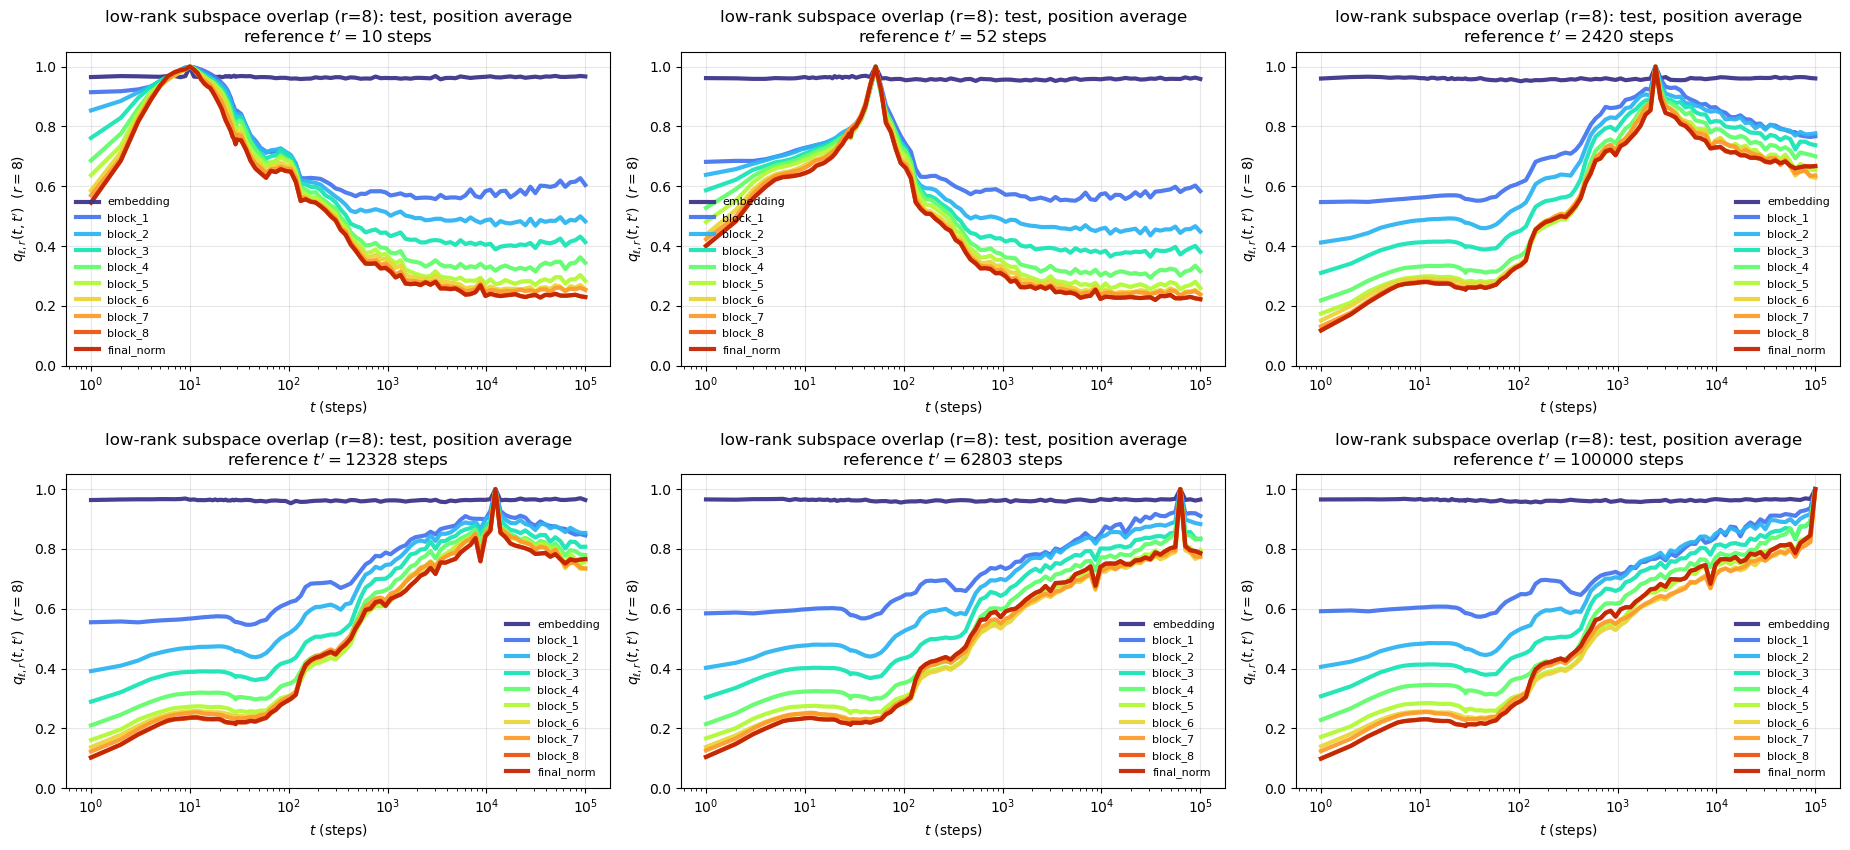

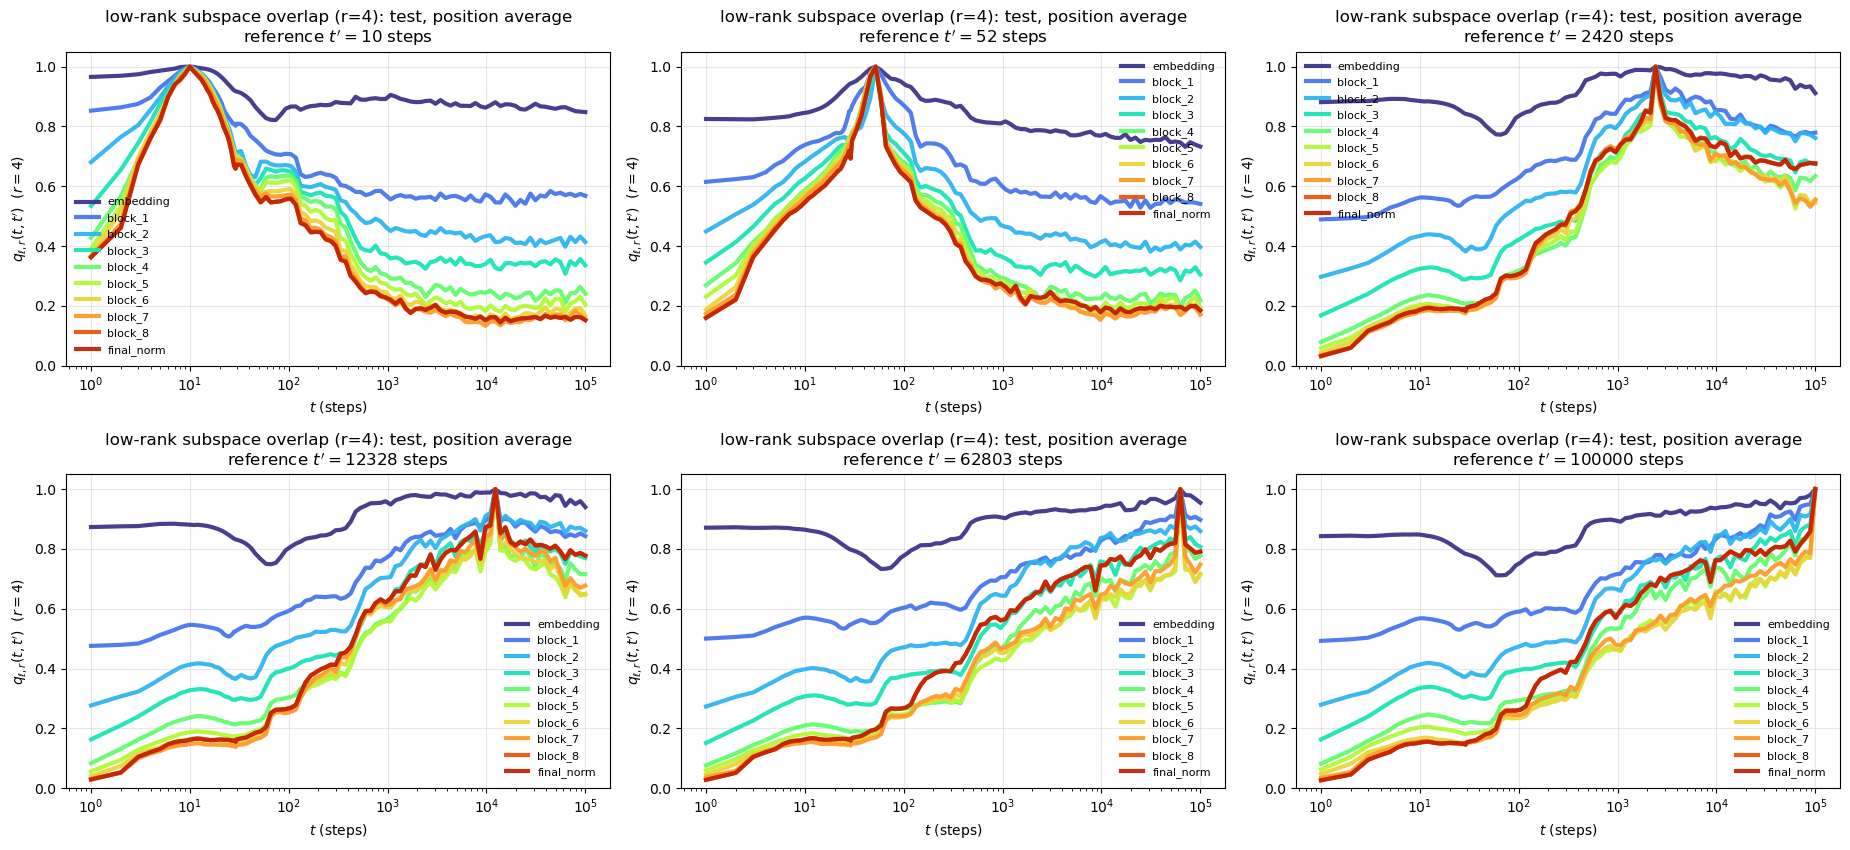

In [26]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r8_TR2_v1/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 50, 2500, 12500, 62500, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r4_TR2_v1/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 50, 2500, 12500, 62500, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

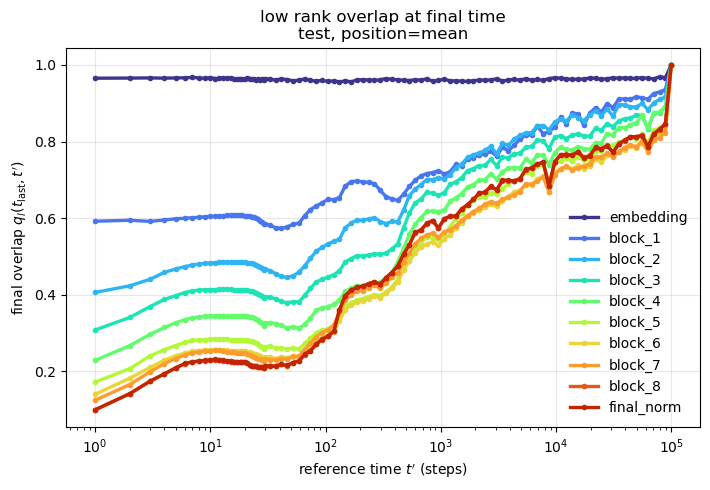

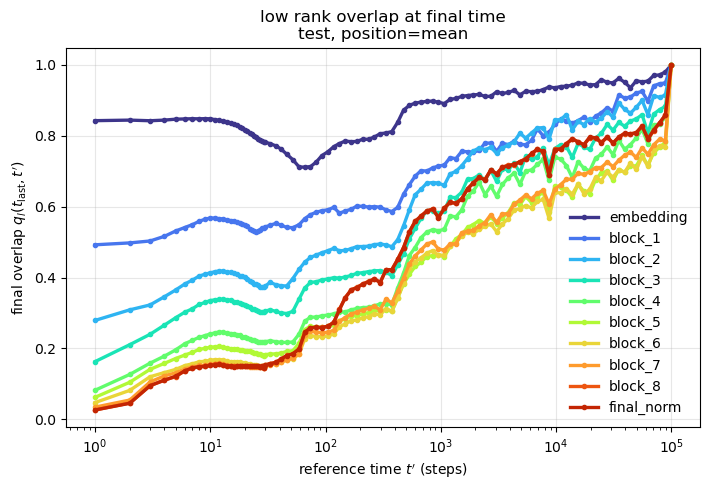

In [27]:
fig, ax, info = plot_ntp_final_overlap_vs_reference_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r8_TR2_v1/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=None,   # all available t'
    time_key="steps",

    xscale="log",
    only_t_ge_tprime=False,
)

fig, ax, info = plot_ntp_final_overlap_vs_reference_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r4_TR2_v1/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=None,   # all available t'
    time_key="steps",

    xscale="log",
    only_t_ge_tprime=False,
)

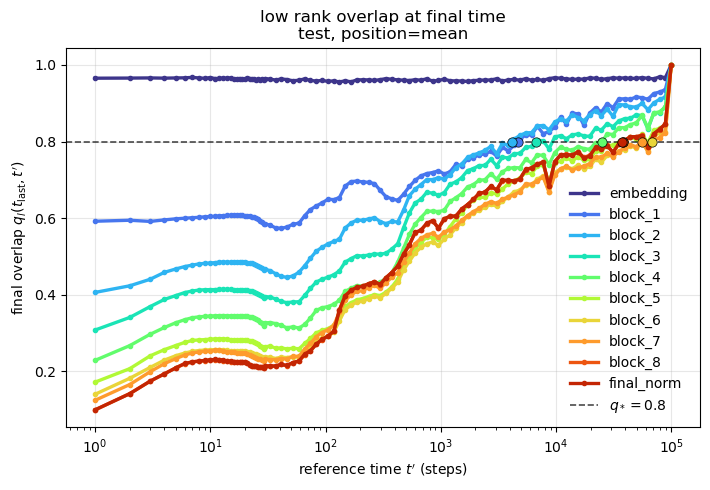

In [7]:
fig, ax, info = plot_ntp_overlap_timescale(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r8_TR2_v1/",
    overlap_target="low_rank",

    overlap_value=0.8,
    crossing="first_upward",

    split="test",
    position="mean",
    reference_times=None,
    time_key="steps",
    xscale="log",
    only_t_ge_tprime=False,
)

# fig, ax, info = plot_ntp_overlap_timescale(
#     results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r4_TR2_v1/",
#     overlap_target="low_rank",

#     overlap_value=0.8,
#     crossing="first_upward",

#     split="test",
#     position="mean",
#     reference_times=None,
#     time_key="steps",
#     xscale="log",
#     only_t_ge_tprime=False,
# )

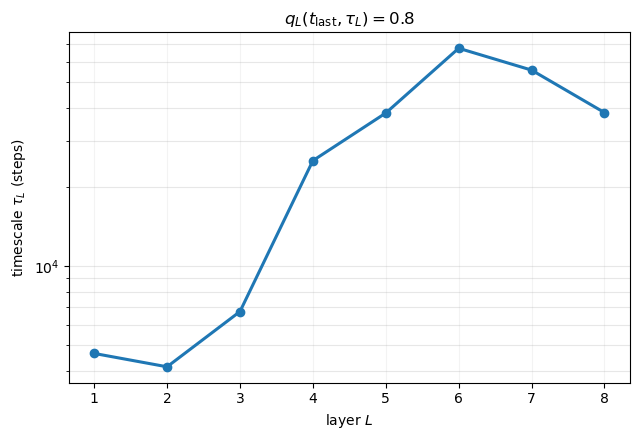

In [8]:
fig_tau, ax_tau, tau_info = plot_ntp_timescale_vs_layer(
    info,
    include_embedding=False,
    include_final_norm=False,
)

#### L=5

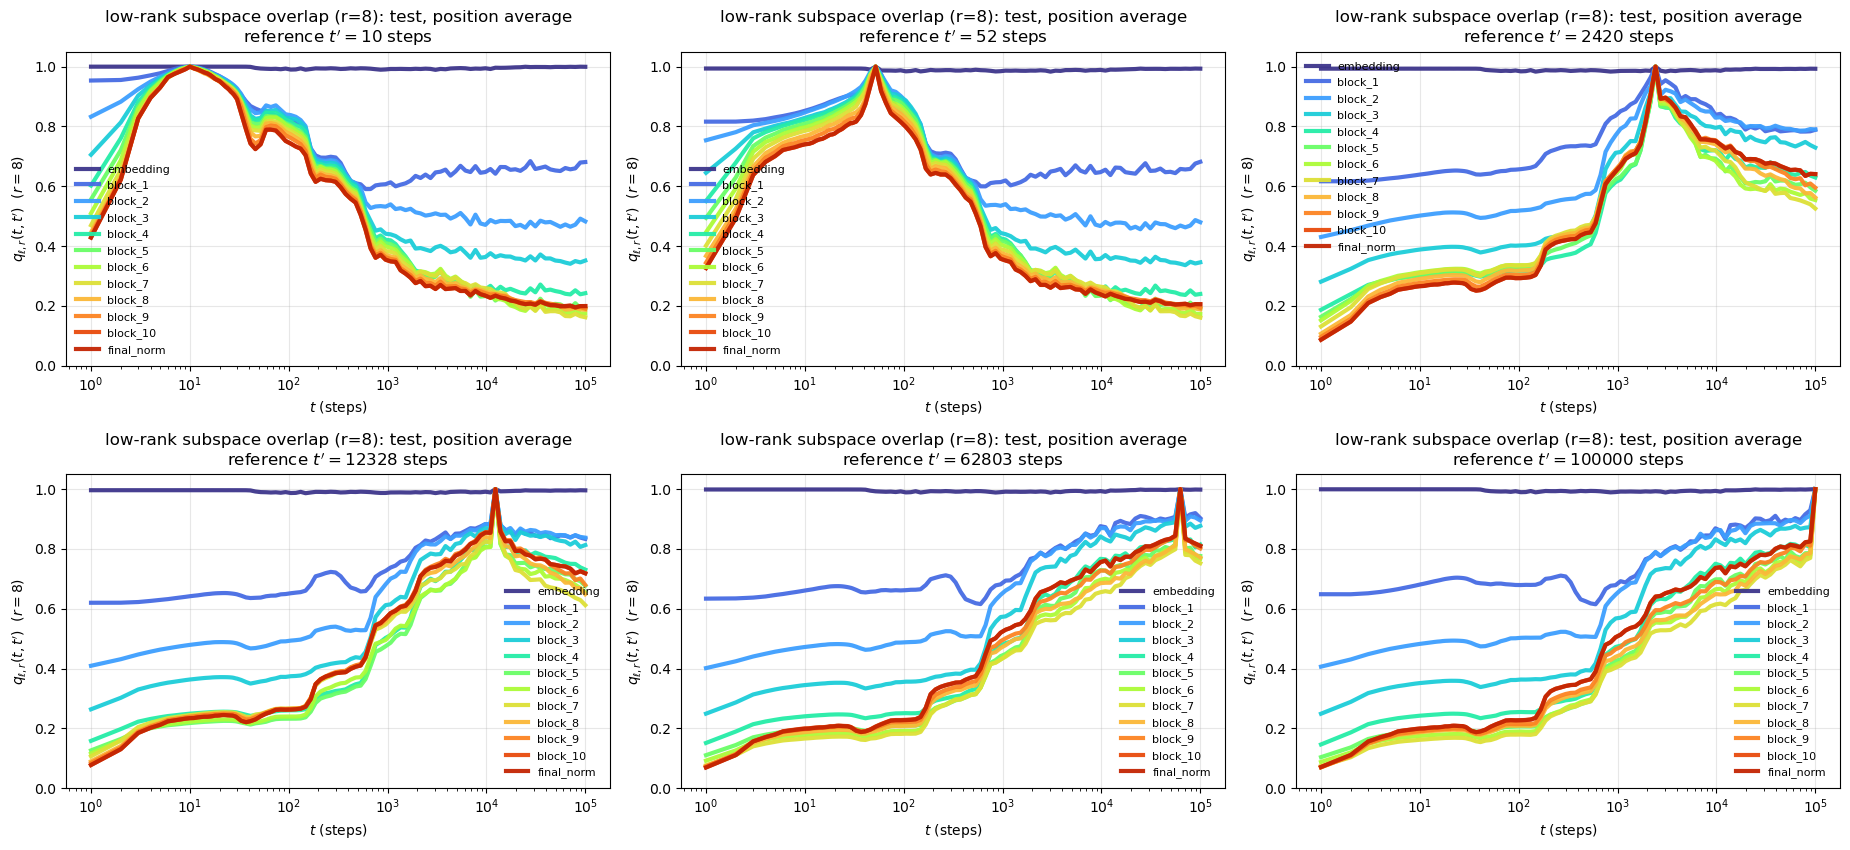

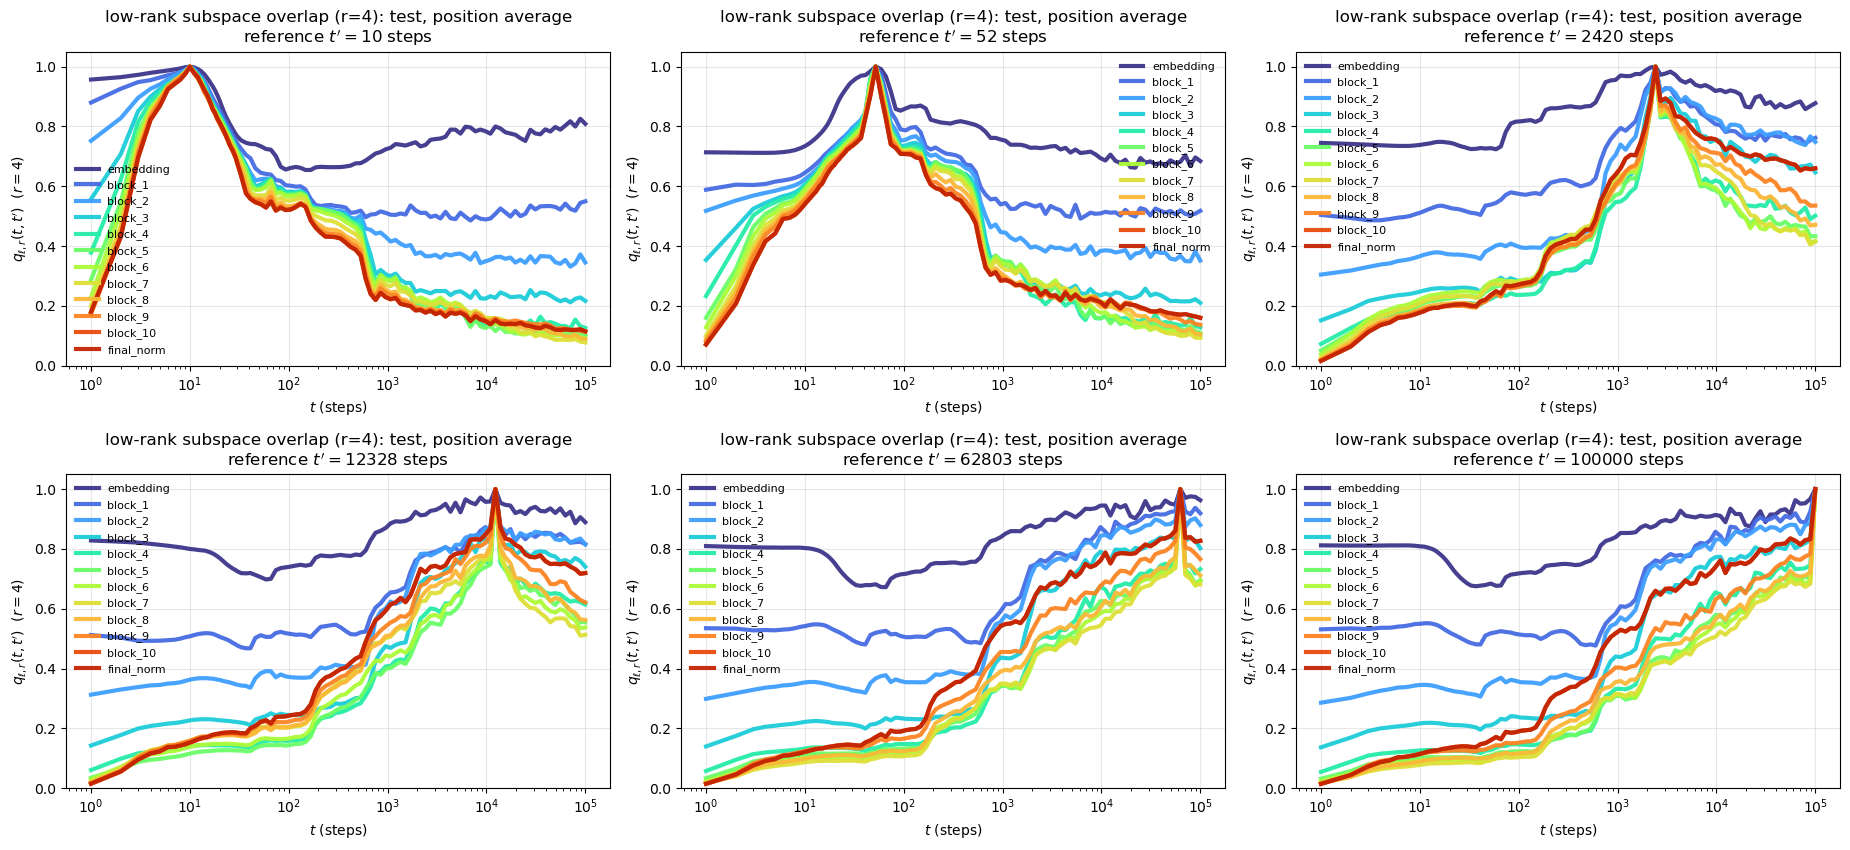

In [9]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L5_low_rank_r8_TR2_v1/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 50, 2500, 12500, 62500, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L5_low_rank_r4_TR2_v1/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 50, 2500, 12500, 62500, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

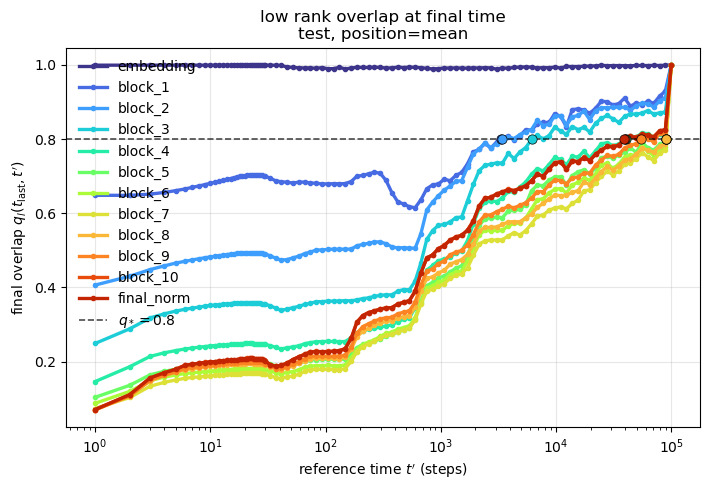

In [18]:
fig, ax, info = plot_ntp_overlap_timescale(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L5_low_rank_r8_TR2_v1/",
    overlap_target="low_rank",

    overlap_value=0.8,
    crossing="first_upward",

    split="test",
    position="mean",
    reference_times=None,
    time_key="steps",
    xscale="log",
    only_t_ge_tprime=False,
)


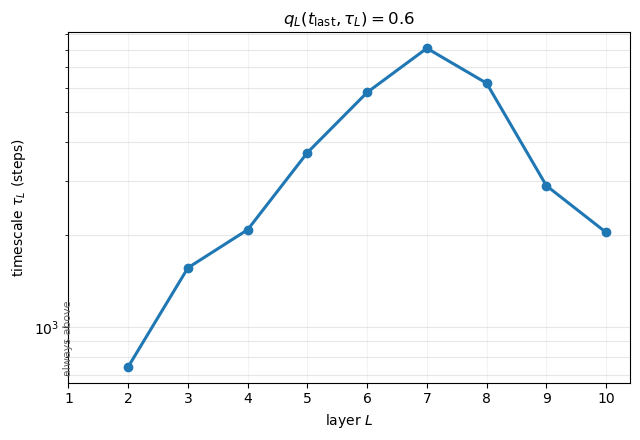

In [ ]:
fig_tau, ax_tau, tau_info = plot_ntp_timescale_vs_layer(
    info,
    include_embedding=False,
    include_final_norm=False,
)

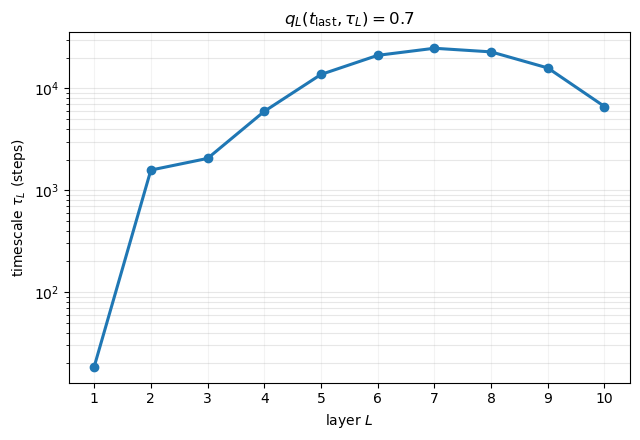

In [17]:
fig_tau, ax_tau, tau_info = plot_ntp_timescale_vs_layer(
    info,
    include_embedding=False,
    include_final_norm=False,
)

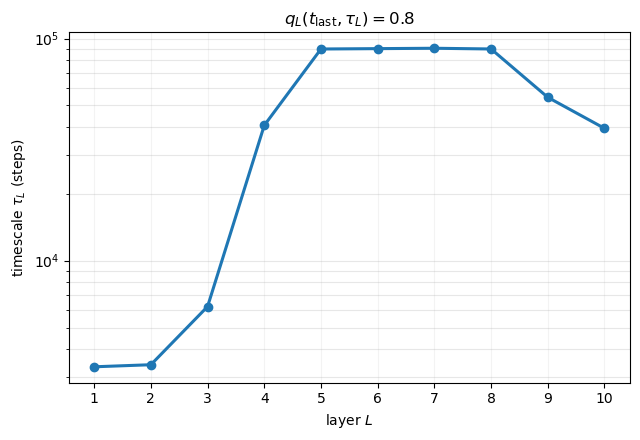

In [19]:
fig_tau, ax_tau, tau_info = plot_ntp_timescale_vs_layer(
    info,
    include_embedding=False,
    include_final_norm=False,
)

#### Tinystories

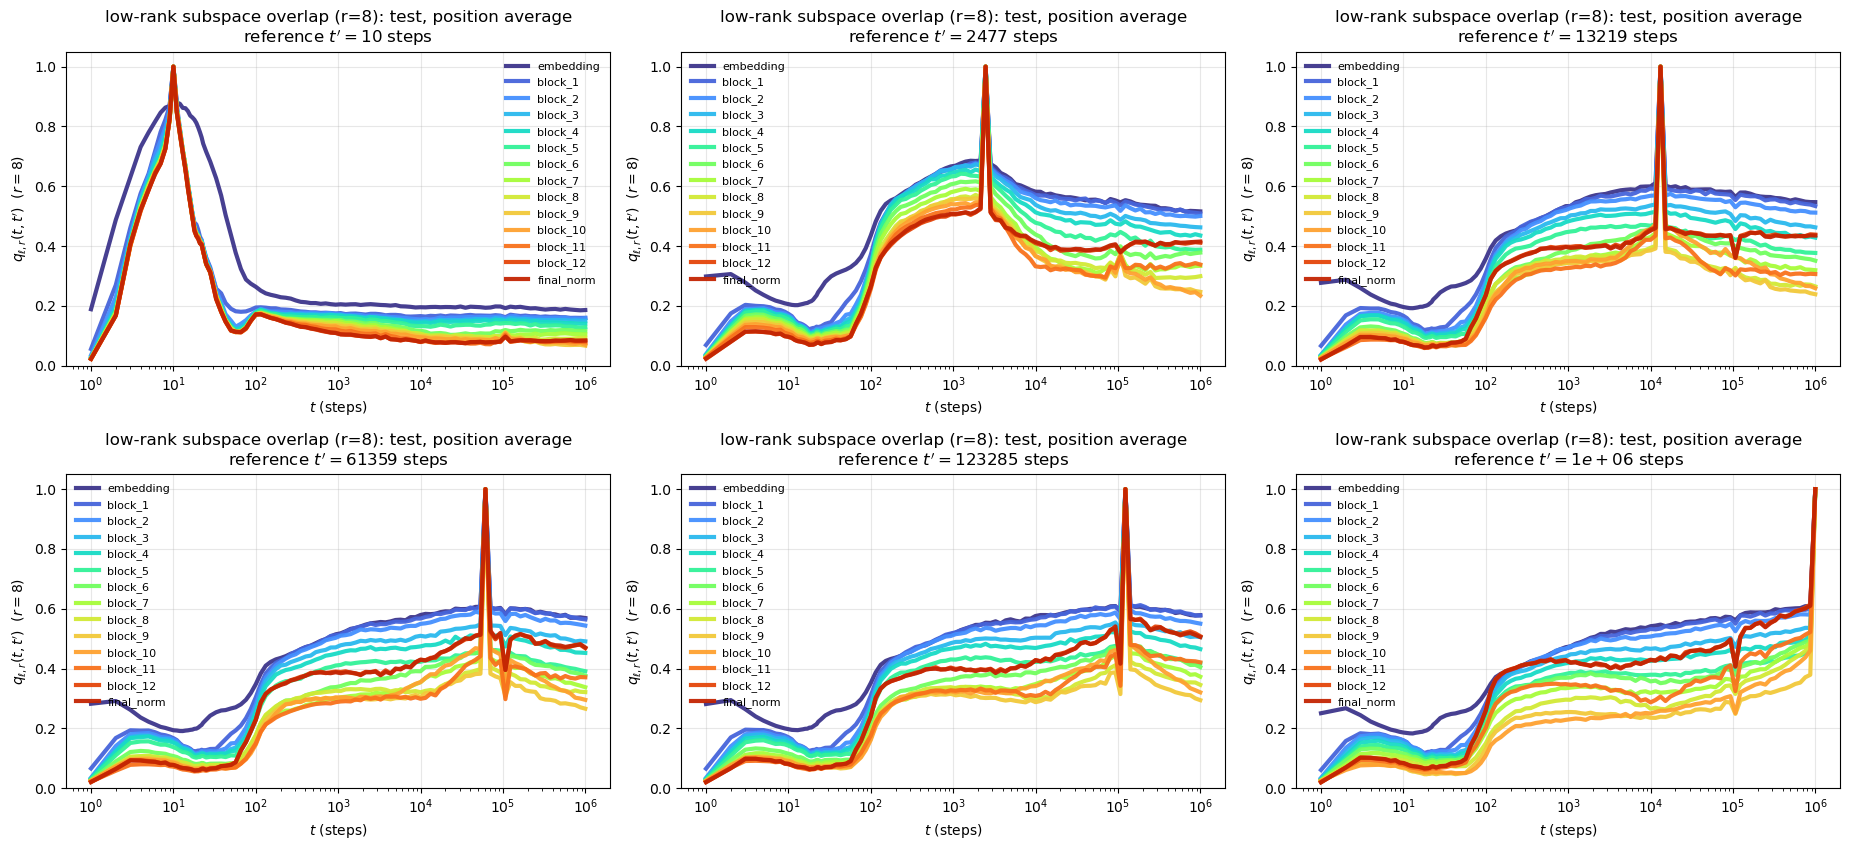

In [24]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/tinystories_low_rank_r8_TR2_v1/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 2500, 12500, 62500, 125000, 1000000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

# fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
#     results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/tinystories_low_rank_r4_TR2_v1/",
#     overlap_target="low_rank",

#     split="test",
#     position="mean",

#     reference_times=[10, 2500, 12500, 62500, 125000, 1000000],
#     time_key="steps",

#     x_mode="absolute",
#     xscale="log",
#     only_t_ge_tprime=False,
# )

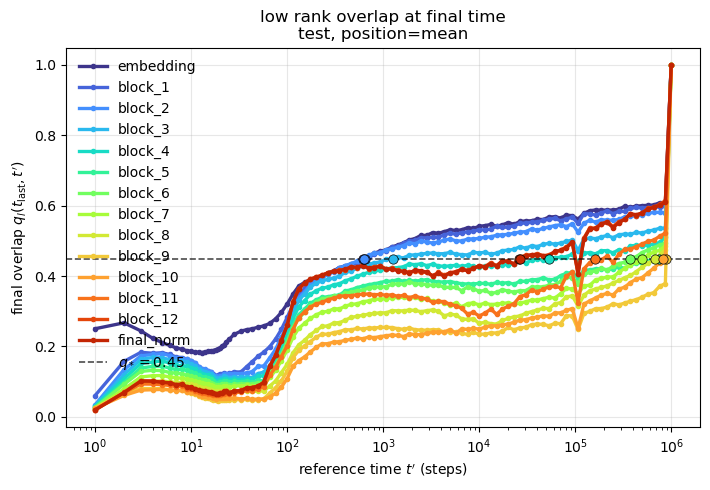

In [32]:
fig, ax, info = plot_ntp_overlap_timescale(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/tinystories_low_rank_r8_TR2_v1/",
    overlap_target="low_rank",

    overlap_value=0.45,
    crossing="first_upward",

    split="test",
    position="mean",
    reference_times=None,
    time_key="steps",
    xscale="log",
    only_t_ge_tprime=False,
)


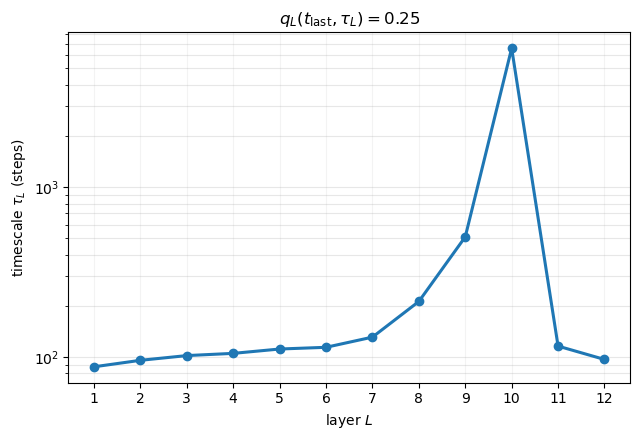

In [28]:
fig_tau, ax_tau, tau_info = plot_ntp_timescale_vs_layer(
    info,
    include_embedding=False,
    include_final_norm=False,
)

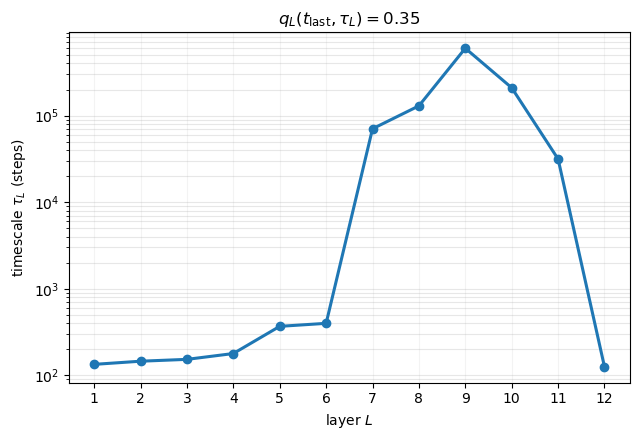

In [31]:
fig_tau, ax_tau, tau_info = plot_ntp_timescale_vs_layer(
    info,
    include_embedding=False,
    include_final_norm=False,
)

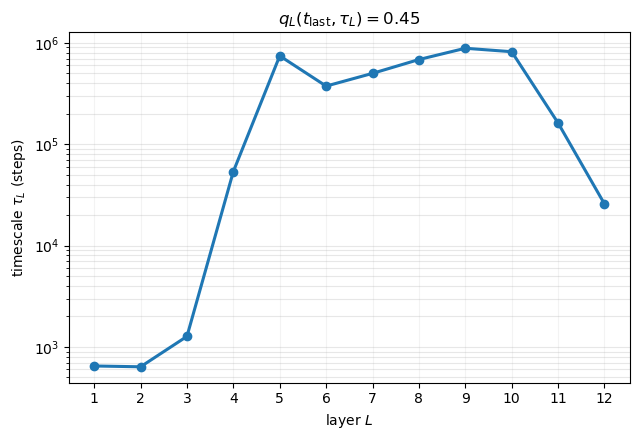

In [33]:
fig_tau, ax_tau, tau_info = plot_ntp_timescale_vs_layer(
    info,
    include_embedding=False,
    include_final_norm=False,
)

### New overlaps, gpt-2

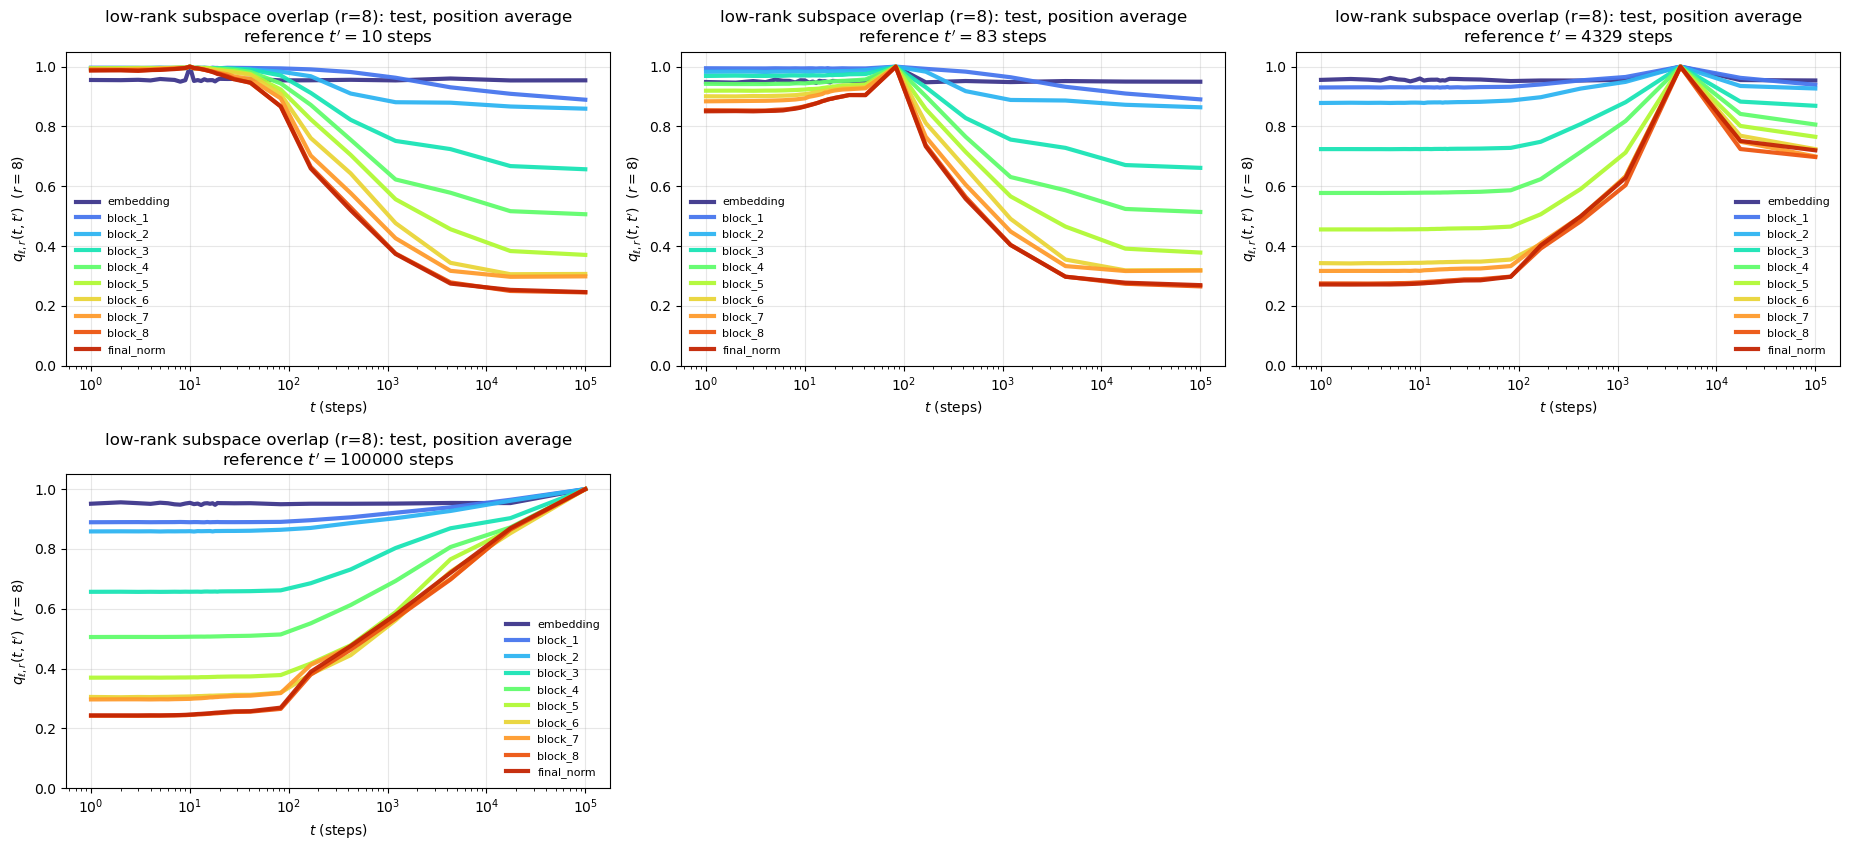

In [29]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r8_v2/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

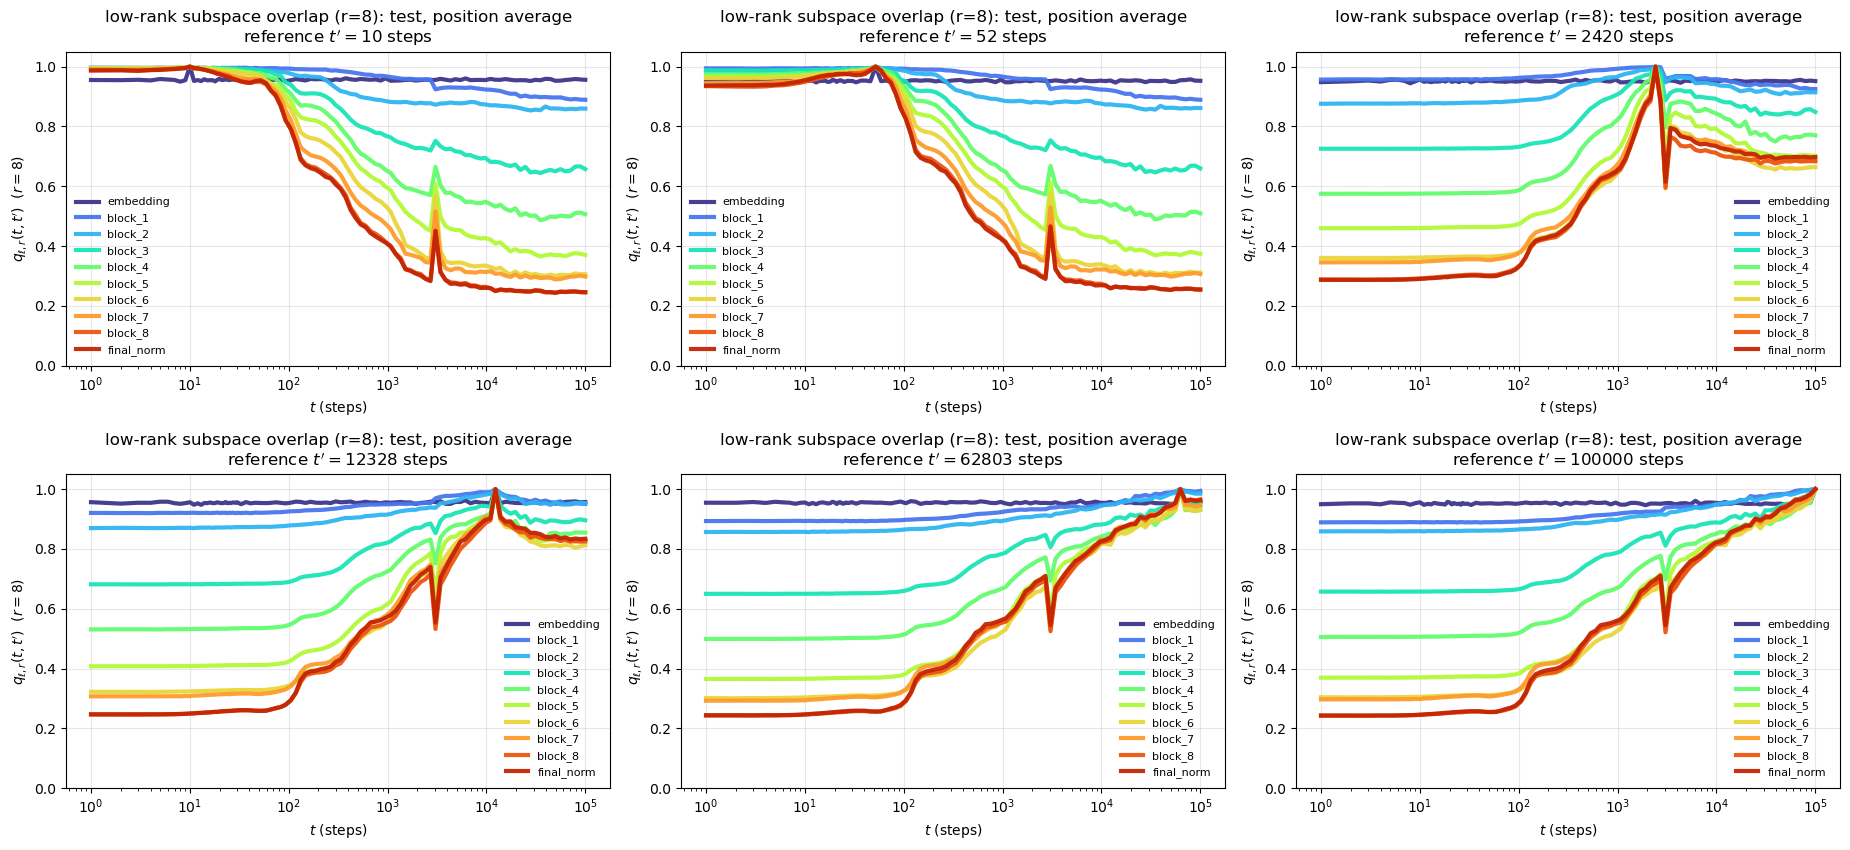

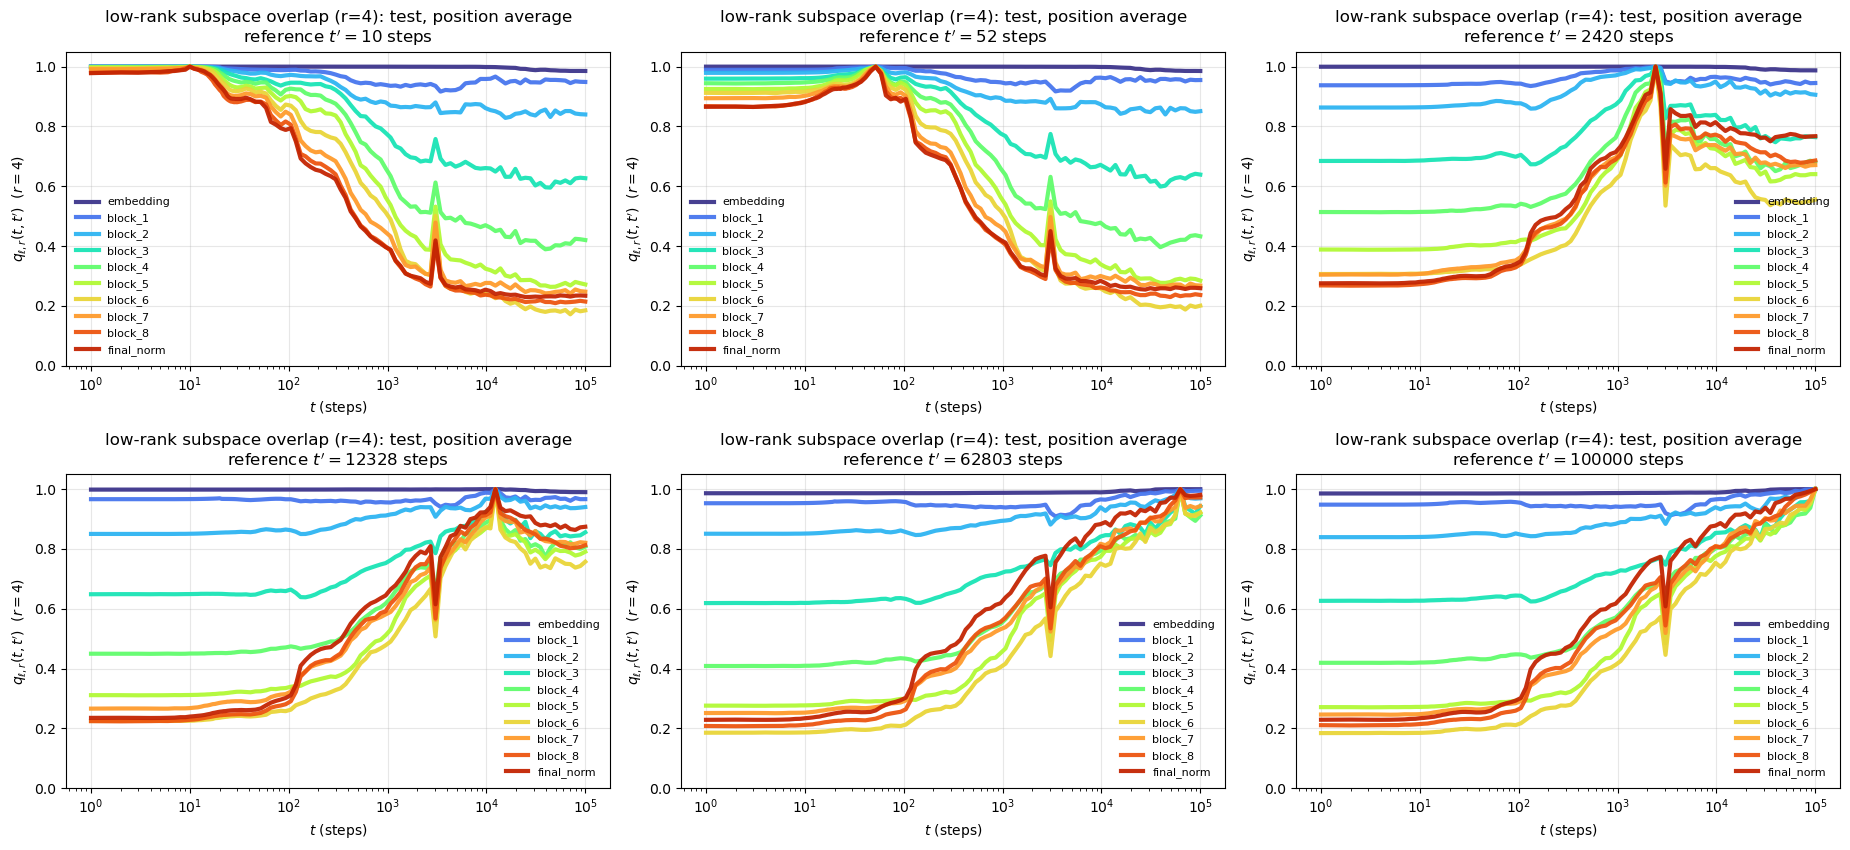

In [30]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r8_v4/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 50, 2500, 12500, 62500, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r4_v4/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 50, 2500, 12500, 62500, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

Exception ignored in: <function NpzFile.__del__ at 0x7f51c4175090>
Traceback (most recent call last):
  File "/home/2a/mb12724/miniconda3/envs/emb/lib/python3.10/site-packages/numpy/lib/npyio.py", line 225, in __del__
    def __del__(self):
KeyboardInterrupt: 


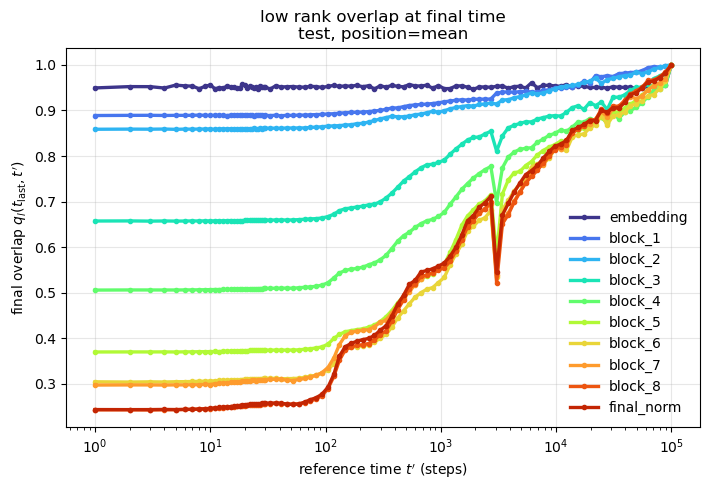

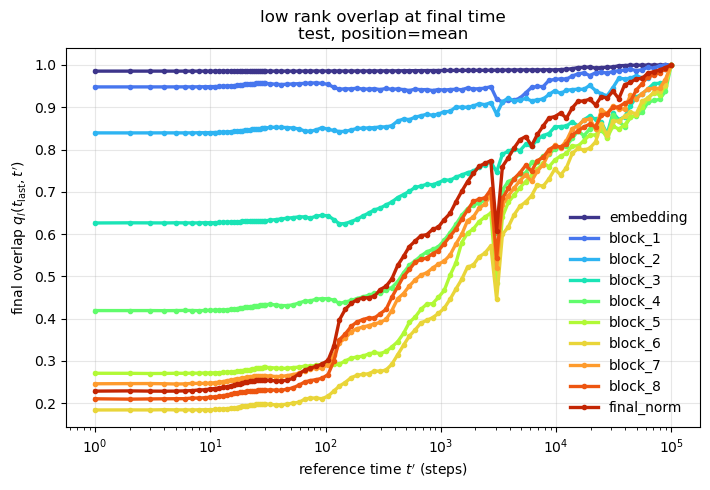

In [31]:
fig, ax, info = plot_ntp_final_overlap_vs_reference_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r8_v4/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=None,   # all available t'
    time_key="steps",

    xscale="log",
    only_t_ge_tprime=False,
)

fig, ax, info = plot_ntp_final_overlap_vs_reference_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r4_v4/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=None,   # all available t'
    time_key="steps",

    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r16_v3/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_low_rank_r16_v3/",
    overlap_target="low_rank",

    split="test",
    position=81,

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L5_low_rank_r16_v3/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L5_low_rank_r16_v3/",
    overlap_target="low_rank",

    split="test",
    position=81,

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L5_low_rank_r8_v4/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 50, 2500, 7500, 30000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L5_low_rank_r4_v4/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=[10, 50, 2500, 7500, 30000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, ax, info = plot_ntp_final_overlap_vs_reference_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L5_low_rank_r8_v4/",
    overlap_target="low_rank",

    split="test",
    position="mean",

    reference_times=None,   # all available t'
    time_key="steps",

    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_novelty_v2/",
    overlap_target="novelty",
    split="test",
    position="mean",
    reference_times=[10, 100, 5000, 100000],
    time_key="steps",
    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_novelty_v3/",
    overlap_target="novelty",
    split="test",
    position="mean",
    reference_times=[10, 100, 5000, 100000],
    time_key="steps",
    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L5_novelty_v3/",
    overlap_target="novelty",
    split="test",
    position="mean",
    reference_times=[10, 100, 5000, 100000],
    time_key="steps",
    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L4_task_v2/",
    overlap_target="task",
    split="test",
    position="mean",
    reference_times=[10, 100, 5000, 100000],
    time_key="steps",
    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/L5_task_v3/",
    overlap_target="task",
    split="test",
    position="mean",
    reference_times=[10, 100, 5000, 100000],
    time_key="steps",
    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

### Previous overlaps

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_weights_TR2_L4_v1/",
    #output_name="",
    overlap_target="weights",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_stream_TR2_L4_v1/",
    #output_name="",
    overlap_target="representations",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_full_L4_v1/",
    #output_name="",
    overlap_target="representations",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

## L=5, v2

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_weights_TR2_L5_v1/",
    #output_name="",
    overlap_target="weights",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_stream_TR2_L5_v1/",
    #output_name="",
    overlap_target="representations",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_full_TR2_L5_v1/",
    #output_name="",
    overlap_target="representations",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

## L=5, v2

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_weights_TR2_L6_v1/",
    #output_name="",
    overlap_target="weights",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_stream_TR2_L6_v1/",
    #output_name="",
    overlap_target="representations",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

## L=3, v1

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_stream_L3_v1/",
    #output_name="",
    overlap_target="representations",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_weights_L3_v1/",
    #output_name="",
    overlap_target="weights",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig_attn, axs_attn, info_attn = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_L3_v1/"
    ),
    overlap_target="weights",

    weight_level="attention",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="Attention weight overlap",
)

In [ ]:
fig_mlp, axs_mlp, info_mlp = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_L3_v1/"
    ),
    overlap_target="weights",

    weight_level="mlp",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="MLP weight overlap",
)

## L=4

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_weights_L4_v1/",
    #output_name="",
    overlap_target="weights",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

In [ ]:
fig_attn, axs_attn, info_attn = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_L4_v1/"
    ),
    overlap_target="weights",

    weight_level="attention",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="Attention weight overlap",
)

In [ ]:
fig_mlp, axs_mlp, info_mlp = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_L4_v1/"
    ),
    overlap_target="weights",

    weight_level="mlp",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="MLP weight overlap",
)